In [13]:
save_figures = False

In [12]:
# Numpy: arrays, numbers, constants, math
import numpy as np

# Matplotlib: plotting
!pip install matplotlib
import matplotlib.pyplot as plt

# This disables certain system messages
import warnings
warnings.filterwarnings('ignore')

# Accessing astronomical datasets
!pip install astroquery
from astroquery.vizier import Vizier
from astroquery.simbad import Simbad
from astroquery.xmatch import XMatch

# Reading and working with Astropy tables
!pip install astropy
from astropy.io import ascii
from astropy import units as units
from astropy.table import Table
from astropy.table import unique
import os

!pip install scipy
from scipy.interpolate import make_smoothing_spline
from scipy.ndimage import gaussian_filter1d

In [4]:
#!pip install google.colab
#from google.colab import drive
#drive.mount('/content/gdrive',force_remount=False)

#my_folder_name = 'Astro_Course'

#main_level = '/content/gdrive/My Drive/'

#my_folder = main_level + my_folder_name + '/'

#from glob import glob
#path_to_your_folder = glob(my_folder)
#if np.size(path_to_your_folder) == 0:
#  print('Please create your folder.')
#  print('Once you have done this, rerun the notebook from the top (e.g., "Runtime --> Run all").')
#  my_folder = main_level
#  print('For now, figures will be saved to the main level of your Google Drive: '+main_level)
#else:
#  print('Your working directory is set to ',my_folder)

In [3]:
hwo = np.genfromtxt('hwo.csv', dtype=str, delimiter=',')
hwo = np.rot90(hwo,axes=(1,0))

vmag = np.float64(hwo[3])
dist = np.float64(hwo[4])
grade = hwo[-1]
maskA = grade == 'A'
maskB = grade == 'B'
maskC = grade == 'C'
hwoa = hwo[:,maskA]
hwob = hwo[:,maskB]
hwoc = hwo[:,maskC]

absmag = np.float64(hwo[3])-5*np.log10(np.float64(hwo[4]))+5
absmaga = np.float64(hwoa[3])-5*np.log10(np.float64(hwoa[4]))+5
absmagb = np.float64(hwob[3])-5*np.log10(np.float64(hwob[4]))+5
absmagc = np.float64(hwoc[3])-5*np.log10(np.float64(hwoc[4]))+5

#print(hwo)
#print(hwoa)
#print(vmag)
#print(dist)
#print(hwoa[3])

In [6]:
print(hwo[5])
print(absmag)

['F7V' 'F6V' 'F8V' 'K3V' 'M1V' 'K4V' 'F6V' 'F5V' 'G2IV-V' 'F6V' 'K4V'
 'G0V' 'G0IV-V' 'F9V' 'M0V' 'K7V' 'K5V' 'F6V' 'F5V' 'G0V' 'K2+V' 'K2.5V'
 'G8IV-V' 'G2V' 'G7V' 'F8V' 'F5.5IV-V' 'K0V' 'G7IV-V' 'F5V' 'G0V' 'K2V'
 'G0V' 'K4V' 'K0-V' 'G3V' 'F5V' 'F4V' 'K0V' 'F2V' 'G0V' 'G9V' 'K5V' 'K1V'
 'K1V' 'K0V' 'G1V' 'G3+IV' 'G0IV' 'F6V' 'G0V' 'G7IV-V' 'G0-V' 'G5V'
 'G2.5V' 'F5V' 'K4V' 'G8-V' 'K5V' 'G2V' 'K1V' 'F4V' 'F7V' 'F9V' 'K3V'
 'G6.5V' 'K2.5V' 'F6V' 'G4IV' 'F9.5V' 'F9V' 'G0V' 'F2V' 'F1V' 'K1V' 'F9V'
 'G2V' 'G8V' 'K0-V' 'M2V' 'G1.5IV-V' 'F9V' 'F4V' 'F8V' 'F3V' 'F6IV-V'
 'K7V' 'G4IV' 'G0V' 'F9V' 'G9-IV-V' 'F7V' 'G0IV-V' 'G2V' 'K0IV-V' 'K2.5V'
 'G0.5V' 'K1V' 'F6V' 'G8+V' 'F9.5V' 'F5V' 'F6V' 'F9V' 'G1.5V' 'G0V'
 'K3.5V' 'F9V' 'F8V' 'F5V' 'F5.5IV-V' 'G7V' 'G2V' 'F6.5V' 'K2.5V' 'K1V'
 'G0V' 'F8V' 'F7V' 'G1.5V' 'G1V' 'F9V' 'K3+V' 'F6V' 'G1.5V' 'K0.5V' 'F8V'
 'F7V' 'F5IV-V' 'K0+IV' 'F9IV-V' 'K2V' 'F3V' 'G6V' 'G5V' 'G1V' 'G2IV'
 'F6V' 'G0V' 'K1.5V' 'F7V' 'F7V' 'F9V' 'G8V' 'G9V' 'G8V' 'K1V' 'F9V' 'K

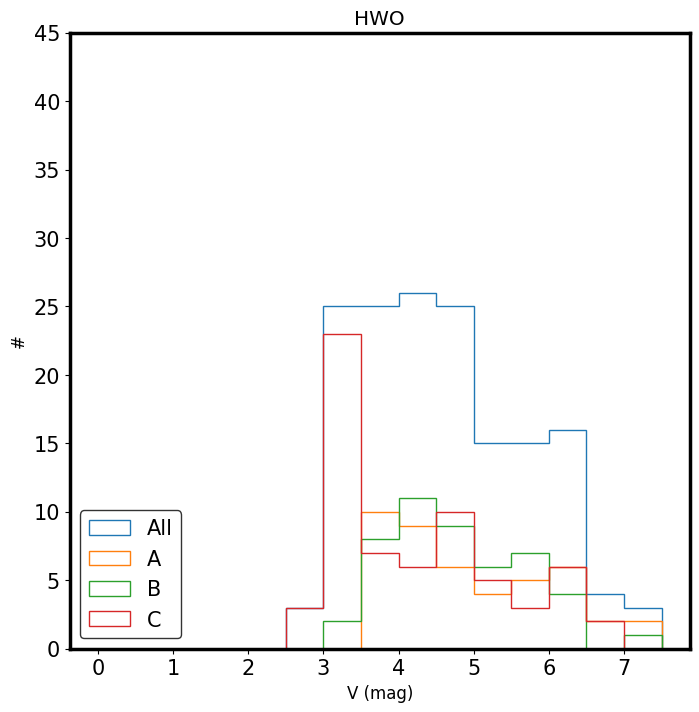

In [7]:
### Make a nice canvas for the figure
figure, axis = plt.subplots(figsize=(8,8))

### Add the data
axis.hist(absmag,label='All',bins=np.arange(0,8,0.5),histtype='step')
axis.hist(absmaga,label='A',bins=np.arange(0,8,0.5),histtype='step')
axis.hist(absmagb,label='B',bins=np.arange(0,8,0.5),histtype='step')
axis.hist(absmagc,label='C',bins=np.arange(0,8,0.5),histtype='step')

axis.legend(loc='lower left', fontsize=15, edgecolor='black')

### Set the x and y limits # after you plot the full sample, choose a minimum and maximum BP-RP and activate this line
axis.set_ylim(0,45) # same but for Gmag; recall that bright stars go on top and faint stars go on the bottom of a CMD

### Add axis labels
axis.set_xlabel('V (mag)',fontsize='large') # Add axis labels. you can use the fontsize= keyword to change the font size.
axis.set_ylabel('#',fontsize='large')

### Add title
axis.set_title('HWO',fontsize='x-large') # Add a title.

# Make plot look nice
axis_border_width = 2.5
fontsize_axis_labels = 15
axis.tick_params(axis='both', which='major', labelsize=fontsize_axis_labels)
axis.spines['top'].set_linewidth(axis_border_width)
axis.spines['left'].set_linewidth(axis_border_width)
axis.spines['right'].set_linewidth(axis_border_width)
axis.spines['bottom'].set_linewidth(axis_border_width)

figure.show()

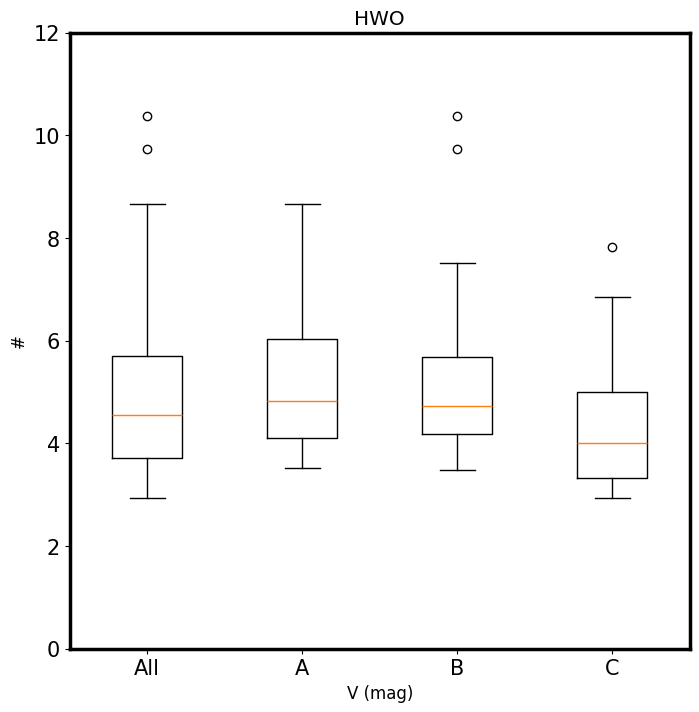

In [8]:
### Make a nice canvas for the figure
figure, axis = plt.subplots(figsize=(8,8))

### Add the data
absmags=[absmag,absmaga,absmagb,absmagc]
axis.boxplot(absmags,tick_labels=['All','A','B','C'])

### Set the x and y limits # after you plot the full sample, choose a minimum and maximum BP-RP and activate this line
axis.set_ylim(0,12) # same but for Gmag; recall that bright stars go on top and faint stars go on the bottom of a CMD

### Add axis labels
axis.set_xlabel('V (mag)',fontsize='large') # Add axis labels. you can use the fontsize= keyword to change the font size.
axis.set_ylabel('#',fontsize='large')

### Add title
axis.set_title('HWO',fontsize='x-large') # Add a title.

# Make plot look nice
axis_border_width = 2.5
fontsize_axis_labels = 15
axis.tick_params(axis='both', which='major', labelsize=fontsize_axis_labels)
axis.spines['top'].set_linewidth(axis_border_width)
axis.spines['left'].set_linewidth(axis_border_width)
axis.spines['right'].set_linewidth(axis_border_width)
axis.spines['bottom'].set_linewidth(axis_border_width)

figure.show()

In [4]:
Simbad.reset_votable_fields()
Simbad.add_votable_fields("mesPLX")
Simbad.add_votable_fields("allfluxes")
Simbad.add_votable_fields('mesFe_h')
#Simbad.add_votable_fields("flux(BP)","flux(RP)")

In [6]:
#print(hwo[0])
#print(hwo[1])
hwodata = Simbad.query_objects(hwo[1])
#print(hwo[1])
#hwodata

unique_result = unique(hwodata, keys="main_id")
hwodata_a = Simbad.query_objects(hwoa[1])
hwodata_b = Simbad.query_objects(hwob[1])
hwodata_c = Simbad.query_objects(hwoc[1])
unique_result_a = unique(hwodata_a, keys="main_id")
unique_result_b = unique(hwodata_b, keys="main_id")
unique_result_c = unique(hwodata_c, keys="main_id")
#print(hwodata['mesplx.plx'])
#hwodata
#unique_result

In [11]:
#print(hwodata['G'][0])
#print(hwodata['K'][0])
#print(hwodata['mesFe_h'][0])
#print(type(hwodata_a))
#print(len(hwodata))
#print(hwodata)
#unique_result_a
for i in unique_result['G']:
    print(i)
len(unique_result['G'])

--
4.7636189460754395
5.803024768829346
4.141092777252197
5.553552150726318
4.916553020477295
4.8739728927612305
5.327651023864746
5.223931789398193
4.861512184143066
4.831335067749023
4.8285908699035645
4.673892021179199
5.602784156799316
4.65714693069458
4.866588115692139
5.403285026550293
5.3183770179748535
4.730510234832764
4.7667131423950195
5.4506449699401855
5.110994815826416
4.532527923583984
3.9873640537261963
5.539217948913574
5.072946071624756
4.999680042266846
4.8501877784729
--
3.9097650051116943
4.757291793823242
--
--
3.801439046859741
4.971372127532959
4.094672203063965
4.093278884887695
2.680732011795044
3.468564987182617
4.8022990226745605
4.988862037658691
4.424264907836914
3.275567054748535
3.364137887954712
4.063914775848389
3.465751886367798
4.322904109954834
3.3200669288635254
4.209557056427002
3.476823091506958
4.089132785797119
3.6944260597229004
5.256284236907959
5.311746120452881
3.9026389122009277
3.999258041381836
4.916409969329834
4.829753875732422
4.65648

139

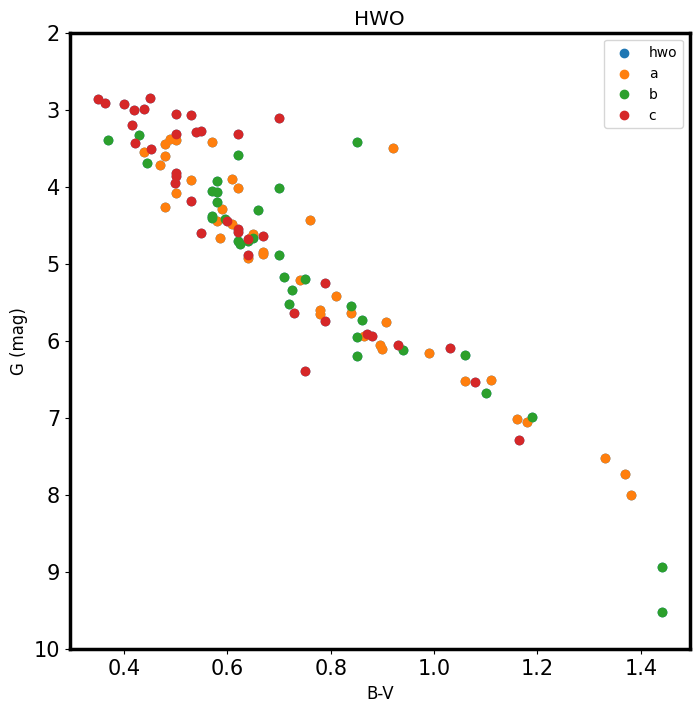

In [12]:
##### Plot BP-RP vs Gmag #####

### Make a nice canvas for the figure
figure, axis = plt.subplots(figsize=(8,8))

### Add the data
axis.scatter(unique_result['B']-unique_result['V'],unique_result['G']-5*np.log10(1000/unique_result['mesplx.plx'])+5,label='hwo') # add in your data here and delete the hashtag to activate the line.
axis.scatter(unique_result_a['B']-unique_result_a['V'],unique_result_a['G']-5*np.log10(1000/unique_result_a['mesplx.plx'])+5,label='a')
axis.scatter(unique_result_b['B']-unique_result_b['V'],unique_result_b['G']-5*np.log10(1000/unique_result_b['mesplx.plx'])+5,label='b')
axis.scatter(unique_result_c['B']-unique_result_c['V'],unique_result_c['G']-5*np.log10(1000/unique_result_c['mesplx.plx'])+5,label='c')



### Set the x and y limits
#axis.set_xlim(-1,4) # after you plot the full sample, choose a minimum and maximum BP-RP and activate this line
axis.set_ylim(10,2) # same but for Gmag; recall that bright stars go on top and faint stars go on the bottom of a CMD

### Add axis labels
axis.set_xlabel('B-V',fontsize='large') # Add axis labels. you can use the fontsize= keyword to change the font size.
axis.set_ylabel('G (mag)',fontsize='large')

### Add title
axis.set_title('HWO',fontsize='x-large') # Add a title.

# Make plot look nice
axis_border_width = 2.5
fontsize_axis_labels = 15
axis.tick_params(axis='both', which='major', labelsize=fontsize_axis_labels)
axis.spines['top'].set_linewidth(axis_border_width)
axis.spines['left'].set_linewidth(axis_border_width)
axis.spines['right'].set_linewidth(axis_border_width)
axis.spines['bottom'].set_linewidth(axis_border_width)
axis.legend()

# Conclude the figure
figure.show()

In [7]:
unique_result

main_id,ra,dec,coo_err_maj,coo_err_min,coo_err_angle,coo_wavelength,coo_bibcode,mesplx.bibcode,mesplx.mespos,mesplx.obscode,mesplx.plx,mesplx.plx_err,mesplx.plx_prec,B,F150W,F200W,F444W,g,G,H,i,I,J,K,r,R,u,U,V,z,mesfe_h.bibcode,mesfe_h.catno,mesfe_h.compstar,mesfe_h.fe_h,mesfe_h.fe_h_prec,mesfe_h.flag,mesfe_h.log_g,mesfe_h.log_g_prec,mesfe_h.mespos,mesfe_h.teff,user_specified_id,object_number_id
,deg,deg,mas,mas,deg,,,,,,mas,mas,,,,,,,,,,,,,,,,,,,,,,,,,cm/s**2,,,unit-degK,,
object,float64,float64,float32,float32,int16,str1,object,object,int16,object,float32,float32,int16,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object,object,float32,int16,str1,float32,int16,int16,int32,object,int64
,--,--,--,--,--,,,,--,,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,,,,--,--,,--,--,--,--,HD 215648 A,7
* 6 Cet,2.81607516478,-15.467977907889997,0.0946,0.0694,90,O,2020yCat.1350....0G,1997A&A...323L..49P,1,,52.94,0.77,2,5.380000114440918,--,--,--,--,4.7636189460754395,3.680000066757202,--,--,3.940000057220459,3.630000114440918,--,--,--,5.349999904632568,4.889999866485596,--,1984Msngr..38...33E,F433,SUN,-0.34,2,,4.1,1,35,6300,HD 693,163
* 10 CVn,191.24752068427662,39.27891614786027,0.0197,0.0174,90,O,2020yCat.1350....0G,1997A&A...323L..49P,1,,57.57,0.64,2,6.5,--,--,--,--,5.803024768829346,4.666999816894531,--,5.119999885559082,4.889999866485596,4.465000152587891,--,5.409999847412109,--,6.46999979019165,5.949999809265137,--,1974A&A....34..263H,F230,SUN,-0.3,2,,4.56,2,45,5793,HD 110897,71
* 10 Tau,54.21826543507,0.40166447161916674,0.1306,0.1093,90,O,2020yCat.1350....0G,2007A&A...474..653V,4,,71.62,0.54,2,5.150000095367432,--,--,--,--,4.141092777252197,3.009999990463257,--,3.7699999809265137,3.259999990463257,2.9100000858306885,--,4.090000152587891,--,5.230000019073486,4.300000190734863,--,1996A&A...314..191G,F,SUN,-0.11,2,,4.0,2,71,5950,HD 22484,131
* 12 Oph,249.08937370706997,-2.3245869511758324,0.0357,0.0165,90,O,2020yCat.1350....0G,1997A&A...323L..49P,1,,102.27,0.85,2,6.550000190734863,--,--,--,--,5.553552150726318,3.880000114440918,--,4.739999771118164,4.329999923706055,3.8299999237060547,--,5.130000114440918,--,7.0,5.769999980926514,--,2015A&A...579A..20M,,,--,--,,4.69,2,42,5306,HD 149661,46
* 15 LMi,147.14738061867,46.02100739317,0.0493,0.0348,90,O,2020yCat.1350....0G,1997A&A...323L..49P,1,,54.26,0.74,2,5.71999979019165,--,--,--,--,4.916553020477295,3.75,--,4.230000019073486,4.050000190734863,3.6089999675750732,--,4.570000171661377,--,5.800000190734863,5.099999904632568,--,2006AJ....131.3069L,,SUN,0.09,2,,4.3,2,14,5946,HD 84737,89
* 17 Cyg,296.6066668696129,33.72759820378805,0.0473,0.0563,90,O,2020yCat.1350....0G,2007A&A...474..653V,4,,47.1,0.26,2,5.460000038146973,--,--,--,--,4.8739728927612305,3.9800000190734863,--,--,4.050000190734863,3.8299999237060547,--,4.699999809265137,--,--,--,--,1986ApJ...309..762B,F474,SUN,0.01,2,,4.0,1,24,6222,HD 187013,27
* 18 Sco,243.90529281485533,-8.369439479286111,0.0659,0.0548,90,O,2020yCat.1350....0G,2007A&A...474..653V,5,,71.94,0.37,2,6.150000095367432,--,--,--,--,5.327651023864746,4.1620001792907715,--,--,4.666999816894531,4.190000057220459,--,--,--,--,5.5,--,2004A&A...427..933K,,,--,--,,--,--,65,5799,HD 146233,48


In [14]:
Simbad.list_votable_fields()[["name", "description"]]

name,description
object,object
mesDiameter,Collection of stellar diameters.
mesPM,Collection of proper motions.
mesISO,Infrared Space Observatory (ISO) observing log.
mesSpT,Collection of spectral types.
allfluxes,"all flux/magnitudes U,B,V,I,J,H,K,u_,g_,r_,i_,z_"
ident,Identifiers of an astronomical object
flux,Magnitude/Flux information about an astronomical object
mesOtype,Other object types associated with an object with origins
mesPLX,Collection of trigonometric parallaxes.


In [15]:
f = open('table.csv')
print(f.read())

SpT   ,Teff  ,logT  , BCv    ,logL  , Mbol ,R_Rsun  , Mv   , B-V   , Bt-Vt , G-V   , Bp-Rp , G-Rp  , M_G   , b-y   , U-B   , V-Rc  , V-Ic  , V-Ks  , J-H   , H-Ks  , M_J   , M_Ks   ,Ks-W1,W1-W2,W1-W3,W1-W4, g-r   ,i-z  ,z-Y  ,Msun  
O3V,44900,4.652,-4.01,5.82,-9.81,13.43,-5.80,-0.330,    ,    ,    ,    ,    ,  ,-1.175,    ,  ,  ,  ,  ,   ,    ,    ,    ,    ,     ,    ,  ,  ,59
O4V,42900,4.632,-3.89,5.65,-9.39,12.13,-5.50,-0.326,    ,    ,    ,    ,    ,  ,-1.160,    ,  ,  ,  ,  ,   ,    ,    ,    ,    ,     ,    ,  ,  ,48
O5V,41400,4.617,-3.76,5.54,-9.11,11.45,-5.35,-0.323,    ,    ,    ,    ,    ,-0.133,-1.150,    ,  ,  ,  ,  ,   ,    ,    ,    ,    ,     ,-0.620,  ,  ,43
O5.5V,40500,4.607,-3.67,5.44,-8.87,10.71,-5.20,-0.322,    ,    ,    ,    ,    ,-0.133,-1.145,    ,  ,  ,  ,  ,   ,    ,    ,    ,    ,     ,-0.620,  ,  ,38
O6V,39500,4.597,-3.57,5.36,-8.67,10.27,-5.10,-0.321,    ,    ,    ,    ,    ,-0.132,-1.140,    ,  ,  ,  ,  ,   ,    ,    ,    ,    ,     ,-0.620,  ,  ,35
O6.5V,38

In [16]:
hwodata2 = np.genfromtxt('hwodata.csv',delimiter=',',dtype=[
    ("ID(HIP)","U20"),
    ("ID(HD)","U20"),
    ("Common Name","U20"),
    ("V(mag)",float),
    ("Dist(pc)",float),
    ("SpT","U20"),
    ("Tier","U20"),
    ("G(mag)",float),
    ("J",float),
    ("H",float),
    ("K",float)],
    encoding="utf-8",names=True
)
print(hwodata2["Gmag"])


[5.878327 4.763619 5.12059  4.07351  2.680732      nan 5.645047 5.467689
 3.320067 5.029543 4.635912 4.82792  4.829754      nan 5.625487 5.508302
 5.383109 4.99968  3.3004   5.410397 6.147864 5.256284      nan 4.330868
 5.812265 3.902639 3.801439 5.344616 5.079608 4.65649  4.063915      nan
 3.465752 4.141093 3.275567 4.113062 5.247617 5.403285      nan 5.318377
 3.087922 5.886492      nan 4.732457 4.525885 4.956077 4.850188 5.51158
 5.990948 5.868166 3.476823 5.805881      nan 5.072946 4.91641       nan
 5.105546 6.231057 5.602784 5.391417 5.38816  5.223932      nan 5.442085
 5.755219 4.988862 6.168385 5.498977 6.284586      nan 5.846635 5.809062
      nan      nan 4.772147 4.916553      nan 5.961174 4.657147 3.909765
 4.673892      nan 4.757292 4.866588 6.551172      nan 5.110995 4.701676
 3.468565 6.198502      nan 4.209557 4.094672 5.803025 4.093279 4.662345
      nan 6.297682 4.532528 6.169921      nan      nan 4.341964      nan
      nan 6.430091 4.480483 5.364037 4.802299 5.4821

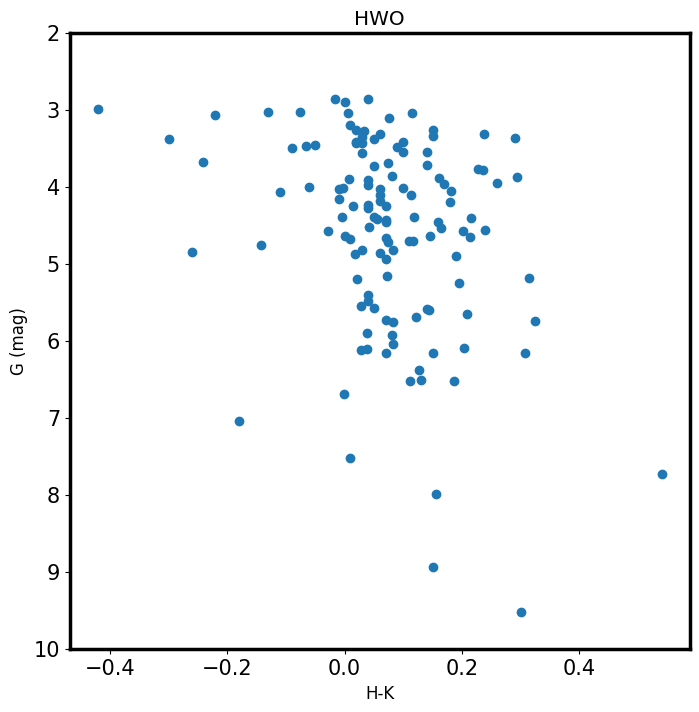

In [17]:
##### Plot BP-RP vs Gmag #####

### Make a nice canvas for the figure
figure, axis = plt.subplots(figsize=(8,8))
#absmag = np.float64(hwo[3])-5*np.log10(np.float64(hwo[4]))+5
### Add the data
axis.scatter(hwodata2['H']-hwodata2['K'],hwodata2['Gmag']-5*np.log10(hwodata2['Distpc'])+5) # add in your data here and delete the hashtag to activate the line.

### Set the x and y limits
#axis.set_xlim(-1,4) # after you plot the full sample, choose a minimum and maximum BP-RP and activate this line
axis.set_ylim(10,2) # same but for Gmag; recall that bright stars go on top and faint stars go on the bottom of a CMD

### Add axis labels
axis.set_xlabel('H-K',fontsize='large') # Add axis labels. you can use the fontsize= keyword to change the font size.
axis.set_ylabel('G (mag)',fontsize='large')

### Add title
axis.set_title('HWO',fontsize='x-large') # Add a title.

# Make plot look nice
axis_border_width = 2.5
fontsize_axis_labels = 15
axis.tick_params(axis='both', which='major', labelsize=fontsize_axis_labels)
axis.spines['top'].set_linewidth(axis_border_width)
axis.spines['left'].set_linewidth(axis_border_width)
axis.spines['right'].set_linewidth(axis_border_width)
axis.spines['bottom'].set_linewidth(axis_border_width)

# Conclude the figure
figure.show()

In [18]:
table = np.genfromtxt('table.csv',delimiter=',',dtype= [
            ('SpT', "U20"),
            ('Teff',int),
            ('logT',float),
            ('BCv',float),
            ('logL',float),
            ('Mbol',float),
            ('R_Rsun',float),
            ('Mv',float),
            ('B-V',float),
            ('Bt-Vt',float),
            ('G-V',float),
            ('Bp-Rp',float),
            ('G-Rp',float),
            ('M_G',float),
            ('b-y',float),
            ('U-B',float),
            ('V-Rc',float),
            ('V-Ic',float),
            ('V-Ks',float),
            ('J-H',float),
            ('H-Ks',float),
            ('M_J',float),
            ('M_Ks',float),
            ('Ks-W1',float),
            ('W1-W2',float),
            ('W1-W3',float),
            ('W1-W4',float),
            ('g-r',float),
            ('i-z',float),
            ('z-Y',float),
            ('Msun',float),
            ], 
        encoding='utf-8',
        names=True)

In [19]:
print(table['JH'])
print(table['Teff'])

[   nan    nan    nan    nan    nan    nan    nan    nan    nan    nan
 -0.164 -0.161 -0.159 -0.153 -0.148 -0.132 -0.113 -0.105 -0.098 -0.092
 -0.084 -0.081 -0.077 -0.067 -0.05  -0.044 -0.032 -0.025 -0.012  0.003
  0.022  0.031  0.043  0.055  0.07   0.086  0.096  0.117  0.14   0.148
  0.159  0.173  0.199  0.213  0.225  0.236  0.249  0.262  0.279  0.293
  0.299  0.304  0.31   0.324  0.327  0.342  0.364  0.387  0.404  0.427
  0.487  0.539  0.568  0.601  0.619  0.626  0.631  0.627  0.62   0.614
  0.608  0.6    0.589  0.579  0.558  0.557  0.564  0.58   0.588  0.605
  0.609  0.613  0.65   0.677  0.69   0.72   0.745  0.76   0.82   0.89
  0.97   1.     1.02   1.06   1.13   1.16   1.18   1.02   1.02   0.86
  0.68   0.35   0.2    0.2    0.2    0.1    0.     0.2    0.2    0.2
  0.1      nan    nan    nan    nan    nan    nan    nan]
[44900 42900 41400 40500 39500 38300 37100 36100 35100 34300 33300 31900
 31400 29000 26000 24500 20600 18500 17000 16400 15700 14500 14000 12300
 10700 10400  9700 

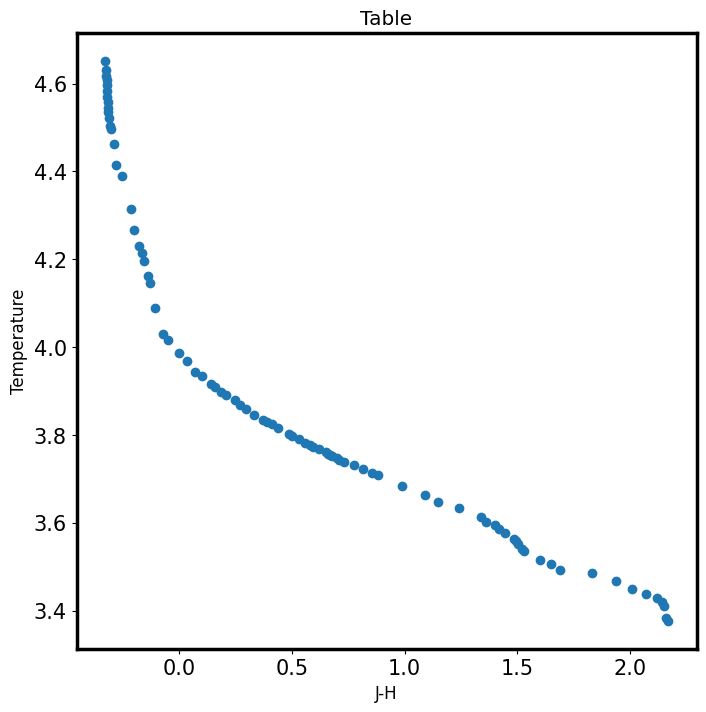

In [20]:
##### Plot BP-RP vs Gmag #####

### Make a nice canvas for the figure
figure, axis = plt.subplots(figsize=(8,8))

### Add the data
axis.scatter(table['BV'],table['logT']) # add in your data here and delete the hashtag to activate the line.
#axis.scatter(hwodata['J']-hwodata['K'],hwodata[''])
### Set the x and y limits
#axis.set_xlim(-2,2) # after you plot the full sample, choose a minimum and maximum BP-RP and activate this line
#axis.set_ylim(20,-7) # same but for Gmag; recall that bright stars go on top and faint stars go on the bottom of a CMD

### Add axis labels
axis.set_xlabel('J-H',fontsize='large') # Add axis labels. you can use the fontsize= keyword to change the font size.
axis.set_ylabel('Temperature',fontsize='large')

### Add title
axis.set_title('Table',fontsize='x-large') # Add a title.

# Make plot look nice
axis_border_width = 2.5
fontsize_axis_labels = 15
axis.tick_params(axis='both', which='major', labelsize=fontsize_axis_labels)
axis.spines['top'].set_linewidth(axis_border_width)
axis.spines['left'].set_linewidth(axis_border_width)
axis.spines['right'].set_linewidth(axis_border_width)
axis.spines['bottom'].set_linewidth(axis_border_width)

# Conclude the figure
figure.show()

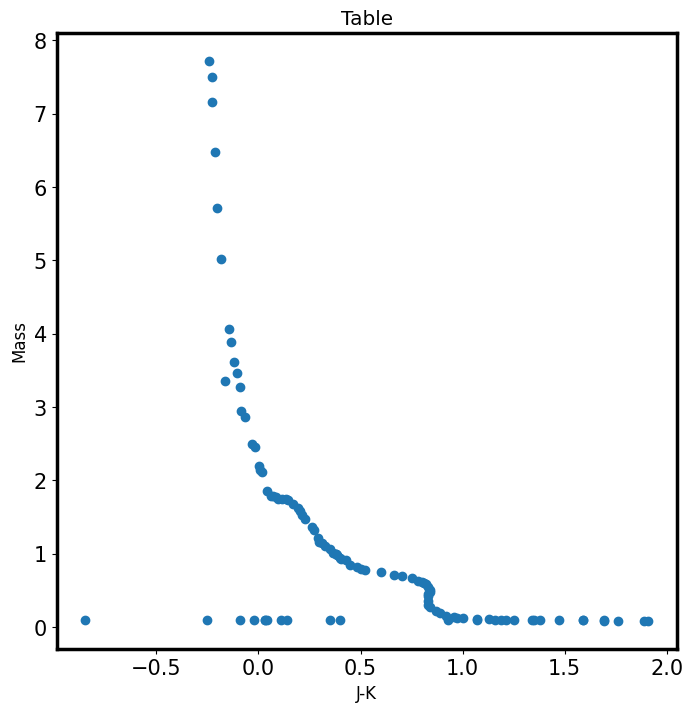

In [21]:
figure, axis = plt.subplots(figsize=(8,8))

### Add the data
axis.scatter(table['M_J']-table['M_Ks'],table['R_Rsun']) # add in your data here and delete the hashtag to activate the line.
### Set the x and y limits
#axis.set_xlim(-2,2) # after you plot the full sample, choose a minimum and maximum BP-RP and activate this line
#axis.set_ylim(20,-7) # same but for Gmag; recall that bright stars go on top and faint stars go on the bottom of a CMD

### Add axis labels
axis.set_xlabel('J-K',fontsize='large') # Add axis labels. you can use the fontsize= keyword to change the font size.
axis.set_ylabel('Mass',fontsize='large')

### Add title
axis.set_title('Table',fontsize='x-large') # Add a title.

# Make plot look nice
axis_border_width = 2.5
fontsize_axis_labels = 15
axis.tick_params(axis='both', which='major', labelsize=fontsize_axis_labels)
axis.spines['top'].set_linewidth(axis_border_width)
axis.spines['left'].set_linewidth(axis_border_width)
axis.spines['right'].set_linewidth(axis_border_width)
axis.spines['bottom'].set_linewidth(axis_border_width)

# Conclude the figure
figure.show()

In [22]:
def get_cluster(Cluster_Name):
  vizier_CantatGaudin2020 = 'J/A+A/640/A1/nodup'    # Cantat-Gaudin et al. (2020) - this is the vizier code for the "Portrait" paper.

  # Set up the Vizier query.
  # First, we want to select only stars in the cluster we are interested in.
  # Second, Cantat-Gaudin+2020 also provides membership probabilities (ranging from 0 to 1).
  #   We will only download stars with membership probabilities greater than 50%.
  query_catalog = Vizier(column_filters={'Cluster': Cluster_Name, 'prob':'>0.5'})

  # By default, Vizier() only downloads the first 50 rows of a table.
  # To deactivate the row limit, set it to -1 (i.e., this will tell it to download the full table)
  query_catalog.ROW_LIMIT = -1

  # Perform the query
  cluster_catalog = query_catalog.get_catalogs(vizier_CantatGaudin2020)[0]

  # Rename some of the columns to simpler names
  cluster_catalog['pmRA*'].name = 'pmRA'
  cluster_catalog['pmDE'].name = 'pmDec'
  cluster_catalog['Plx'].name = 'Parallax'
  cluster_catalog['RA_ICRS'].name = 'RA'
  cluster_catalog['DE_ICRS'].name = 'Dec'

  # Remove some unnecessary columns
  cluster_catalog.remove_columns(['o_Gmag', 'proba', 'Cluster', '_RA.icrs', '_DE.icrs','Teff50'])

  # Return the catalog
  return cluster_catalog

In [8]:
table2 = Table([unique_result["ra"],unique_result["dec"]],names=('ra','dec'))
table2a = Table([unique_result_a["ra"],unique_result_a["dec"]],names=('ra','dec'))
table2b = Table([unique_result_b["ra"],unique_result_b["dec"]],names=('ra','dec'))
table2c = Table([unique_result_c["ra"],unique_result_c["dec"]],names=('ra','dec'))
table2

ra,dec
deg,deg
float64,float64
--,--
2.81607516478,-15.467977907889997
191.24752068427662,39.27891614786027
54.21826543507,0.40166447161916674
249.08937370706997,-2.3245869511758324
147.14738061867,46.02100739317
296.6066668696129,33.72759820378805
243.90529281485533,-8.369439479286111


In [24]:
f = open("table2.txt","w")
for i in range(0,len(table2)):
    f.write(str(table2['ra'][i])+' '+str(table2['dec'][i])+'\n')



In [25]:
#Cross-Match with Gaia DR3
#search radius
search_radius_CB = 10
#Xmatch query
gaiatable = XMatch.query(cat1=table2,
                            cat2='vizier:I/355/gaiadr3',
                            max_distance=search_radius_CB * units.arcsec,
                            colRA1='ra', colDec1='dec')
#cross-matched table
gaiatable.sort("angDist")
best_match = unique(gaiatable, keys="ra")
best_match = best_match[best_match["angDist"] < 10.0]
best_match = best_match[best_match["Gmag"] < 10.0]
gaiatable2 = Table([best_match["ra"], best_match["dec"], best_match["Source"].astype("int64")], names=("ra", "dec", "gaia_dr3_source_id"))
#best_match
gaiatable2
#print(best_match)
#count=0
#for i in range(0,len(gaiatable['Gmag'])):
#    if gaiatable['Gmag'][i]<7.0 and gaiatable['angDist'][i]<5.0:
#        print(str(gaiatable['Gmag'][i])+' '+str(gaiatable['angDist'][i]))
#    count+=1
#print(count)
#gaiatable

ra,dec,gaia_dr3_source_id
float64,float64,int64
1.6532666952450004,29.021503526080565,2860924621205256704
2.81607516478,-15.467977907889997,2416611663182821120
2.93342115391,-35.13311470919,2309813109479463040
11.439970539640003,-47.551984068669995,4975284381908412672
12.276227476217503,57.81517728880999,425040000962497792
12.5316206769625,-10.644328847899445,2473608009504466688
13.2674851758,61.12397202496,427322415301550208
18.94203792959625,-68.8759448102925,4692263904164105856
24.948186303551665,-56.196448108297496,4911306239828325760


# GAIA TABLE

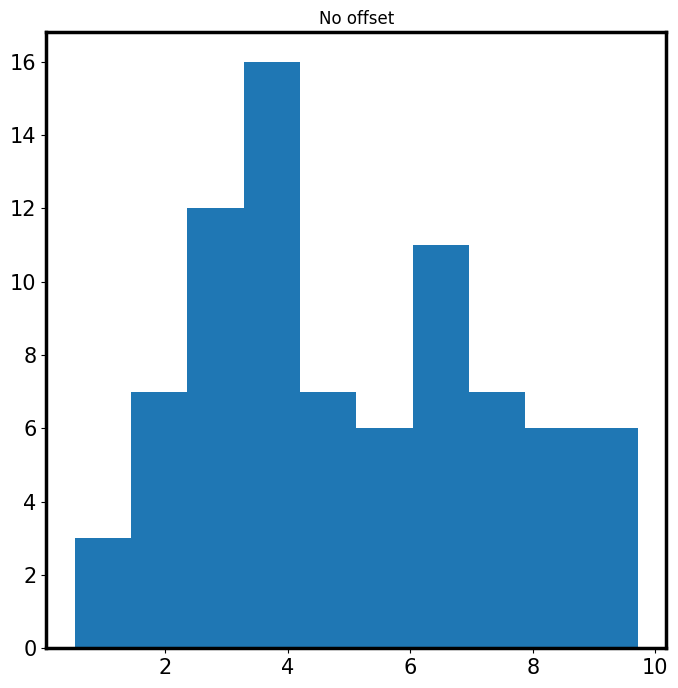

In [26]:
figure, axis=plt.subplots(figsize=(8,8))

axis.hist(best_match['angDist'])
axis_border_width = 2.5
fontsize_axis_labels = 15
axis.tick_params(axis='both', which='major', labelsize=fontsize_axis_labels)
axis.spines['top'].set_linewidth(axis_border_width)
axis.spines['left'].set_linewidth(axis_border_width)
axis.spines['right'].set_linewidth(axis_border_width)
axis.spines['bottom'].set_linewidth(axis_border_width)
axis.set_title("No offset")

figure.show()

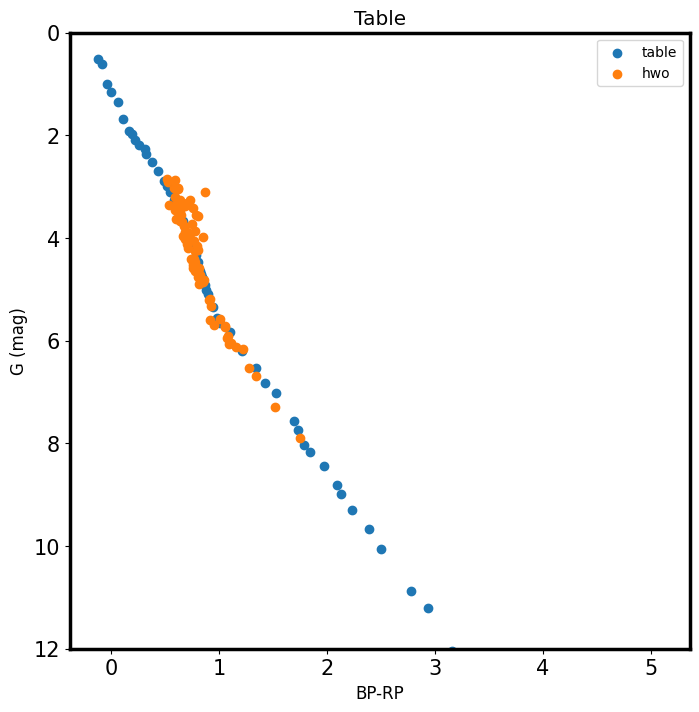

In [27]:
##### Plot BP-RP vs Gmag #####

### Make a nice canvas for the figure
figure, axis = plt.subplots(figsize=(8,8))

### Add the data
axis.scatter(table['BpRp'],table['M_G'],label='table') 
axis.scatter(best_match['BP-RP'],best_match['Gmag']-5*np.log10(1000/best_match['Plx'])+5,label='hwo')

#axis.scatter(hwodata['J']-hwodata['K'],hwodata[''])
### Set the x and y limits
#axis.set_xlim(-2,2) # after you plot the full sample, choose a minimum and maximum BP-RP and activate this line
axis.set_ylim(12,0) # same but for Gmag; recall that bright stars go on top and faint stars go on the bottom of a CMD

### Add axis labels
axis.set_xlabel('BP-RP',fontsize='large') # Add axis labels. you can use the fontsize= keyword to change the font size.
axis.set_ylabel('G (mag)',fontsize='large')

### Add title
axis.set_title('Table',fontsize='x-large') # Add a title.

# Make plot look nice
axis_border_width = 2.5
fontsize_axis_labels = 15
axis.tick_params(axis='both', which='major', labelsize=fontsize_axis_labels)
axis.spines['top'].set_linewidth(axis_border_width)
axis.spines['left'].set_linewidth(axis_border_width)
axis.spines['right'].set_linewidth(axis_border_width)
axis.spines['bottom'].set_linewidth(axis_border_width)
axis.legend()

# Conclude the figure
figure.show()

In [28]:
tablea = Table([unique_result_a["ra"],unique_result_a["dec"]],names=('ra','dec'))
tableb = Table([unique_result_b["ra"],unique_result_b["dec"]],names=('ra','dec'))
tablec = Table([unique_result_c["ra"],unique_result_c["dec"]],names=('ra','dec'))

search_radius_CB = 5
gaiatablea = XMatch.query(cat1=tablea,
                            cat2='vizier:I/355/gaiadr3',
                            max_distance=search_radius_CB * units.arcsec,
                            colRA1='ra', colDec1='dec')
gaiatableb = XMatch.query(cat1=tableb,
                            cat2='vizier:I/355/gaiadr3',
                            max_distance=search_radius_CB * units.arcsec,
                            colRA1='ra', colDec1='dec')
gaiatablec = XMatch.query(cat1=tablec,
                            cat2='vizier:I/355/gaiadr3',
                            max_distance=search_radius_CB * units.arcsec,
                            colRA1='ra', colDec1='dec')
gaiatablea.sort("angDist")
best_matcha = unique(gaiatablea, keys="ra")
best_matcha = best_matcha[best_matcha["Gmag"] < 10.0]
#cross-matched table
gaiatableb.sort("angDist")
best_matchb = unique(gaiatableb, keys="ra")
best_matchb = best_matchb[best_matchb["Gmag"] < 10.0]
#cross-matched table
gaiatablec.sort("angDist")
best_matchc = unique(gaiatablec, keys="ra")
best_matchc = best_matchc[best_matchc["Gmag"] < 10.0]

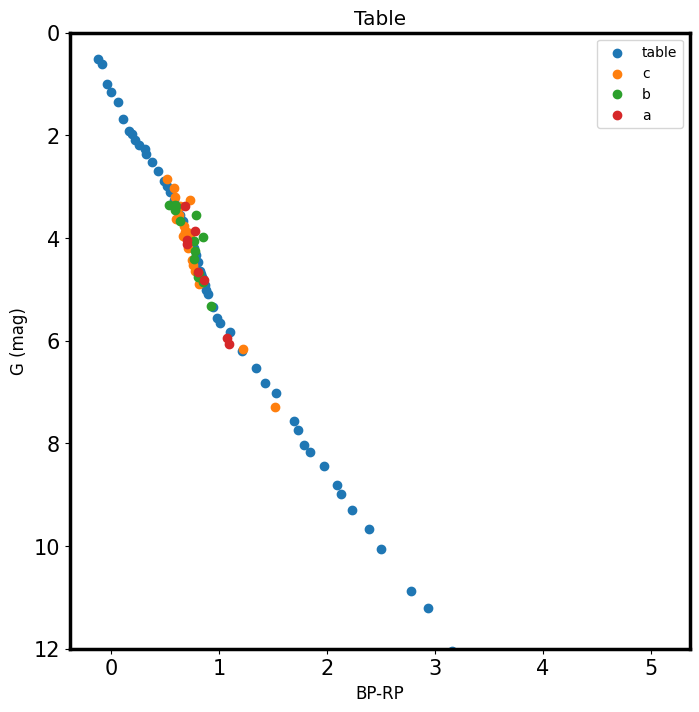

In [29]:
### Make a nice canvas for the figure
figure, axis = plt.subplots(figsize=(8,8))

### Add the data
axis.scatter(table['BpRp'],table['M_G'],label='table') 
axis.scatter(best_matchc['BP-RP'],best_matchc['Gmag']-5*np.log10(1000/best_matchc['Plx'])+5,label='c')

axis.scatter(best_matchb['BP-RP'],best_matchb['Gmag']-5*np.log10(1000/best_matchb['Plx'])+5,label='b')
axis.scatter(best_matcha['BP-RP'],best_matcha['Gmag']-5*np.log10(1000/best_matcha['Plx'])+5,label='a')

#axis.scatter(hwodata['J']-hwodata['K'],hwodata[''])
### Set the x and y limits
#axis.set_xlim(-2,2) # after you plot the full sample, choose a minimum and maximum BP-RP and activate this line
axis.set_ylim(12,0) # same but for Gmag; recall that bright stars go on top and faint stars go on the bottom of a CMD

### Add axis labels
axis.set_xlabel('BP-RP',fontsize='large') # Add axis labels. you can use the fontsize= keyword to change the font size.
axis.set_ylabel('G (mag)',fontsize='large')

### Add title
axis.set_title('Table',fontsize='x-large') # Add a title.

# Make plot look nice
axis_border_width = 2.5
fontsize_axis_labels = 15
axis.tick_params(axis='both', which='major', labelsize=fontsize_axis_labels)
axis.spines['top'].set_linewidth(axis_border_width)
axis.spines['left'].set_linewidth(axis_border_width)
axis.spines['right'].set_linewidth(axis_border_width)
axis.spines['bottom'].set_linewidth(axis_border_width)
axis.legend()

# Conclude the figure
figure.show()

In [30]:
best_matcha

angDist,ra,dec,DR3Name,RAdeg,DEdeg,errHalfMaj,errHalfMin,errPosAng,SolID,Source,RandomI,e_RAdeg,e_DEdeg,Plx,e_Plx,RPlx,PM,pmRA,e_pmRA,pmDE,e_pmDE,RADEcor,RAPlxcor,RApmRAcor,RApmDEcor,DEPlxcor,DEpmRAcor,DEpmDEcor,PlxpmRAcor,PlxpmDEcor,pmRApmDEcor,NAL,NAC,NgAL,NbAL,gofAL,chi2AL,epsi,sepsi,Solved,APF,nueff,pscol,e_pscol,RApscolCorr,DEpscolCorr,PlxpscolCorr,pmRApscolCorr,pmDEpscolCorr,MatchObsA,Nper,amax,MatchObs,IPDgofha,IPDgofhp,IPDfmp,IPDfow,RUWE,Dup,o_Gmag,FG,e_FG,RFG,Gmag,e_Gmag,o_BPmag,FBP,e_FBP,RFBP,BPmag,e_BPmag,o_RPmag,FRP,e_FRP,RFRP,RPmag,e_RPmag,E(BP/RP),NBPcont,NBPblend,NRPcont,NRPblend,Mode,BP-RP,BP-G,G-RP,RV,e_RV,n_RV,o_RV,o_RVd,RVNper,RVS/N,RVgof,RVchi2,RVTdur,RVamp,RVtempTeff,RVtemplogg,RVtemp[Fe/H],Vatmparam,vbroad,e_Vbroad,o_Vbroad,GRVSmag,e_GRVSmag,o_GRVSmag,RVSS/N,VarFlag,PQSO,PGal,PSS,Teff,b_Teff,B_Teff,logg,b_logg,B_logg,[Fe/H],b_[Fe/H],B_[Fe/H],Dist,b_Dist,B_Dist,A0,b_A0,B_A0,AG,b_AG,B_AG,E(BP-RP),b_E(BP-RP),B_E(BP-RP),Lib,RAJ2000,DEJ2000,e_RAJ2000,e_DEJ2000,RADEcorJ2000
arcsec,,,,deg,deg,arcsec,arcsec,deg,,,,mas,mas,mas,mas,,mas / yr,mas / yr,mas / yr,mas / yr,mas / yr,,,,,,,,,,,,,,,,,mas,,,,1 / um,1 / um,1 / um,,,,,,,,mas,,,deg,,,,,,electron/s,electron/s,,mag,,,electron/s,electron/s,,mag,,,electron/s,electron/s,,mag,,,,,,,,mag,mag,mag,km / s,km / s,,,,,,,,d,km / s,K,dex(cm / s2),dex,,km / s,km / s,,mag,mag,,,,,,,K,K,K,dex(cm / s2),dex(cm / s2),dex(cm / s2),dex,dex,dex,pc,pc,pc,mag,mag,mag,mag,mag,mag,mag,mag,mag,,deg,deg,,,
float64,float64,float64,str28,float64,float64,float32,float32,float32,int64,int64,int32,float32,float32,float64,float32,float32,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,float32,float32,float32,float32,uint8,bool,float32,float32,float32,float32,float32,float32,float32,float32,int16,uint8,float32,int16,float32,float32,uint8,uint8,float32,uint8,int16,float64,float32,float32,float32,float32,int16,float64,float32,float32,float32,float32,int16,float64,float32,float32,float32,float32,float32,int16,int16,int16,int16,uint8,float32,float32,float32,float32,float32,uint8,int16,int16,uint8,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,uint8,float32,float32,int16,float32,str13,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,str7,float64,float64,float64,float64,float32
4.511867,2.81607516478,-15.467977907889997,Gaia DR3 2416611663182821120,2.81569320276,-15.46917592096,0.0,0.0,87.0,1636148068921376768,2416611663182821120,1102735586,0.0946,0.0694,52.9489,0.0958,552.4289,281.988,-82.828,0.117,-269.549,0.082,0.0338,0.199,0.4529,-0.0974,0.0726,-0.0876,0.5622,0.0647,0.0169,0.1786,311,311,299,12,15.3012,30459.0,0.733,791.22,95,False,--,1.6006,0.0177,-0.072,0.069,-0.143,0.06,-0.077,35,16,0.170996,43,0.009378,4.773,0,0,1.693,0,334,234152625.6257,189780.0,1233.81,4.763619,0.002892,37,134123000.0,92548.9,1449.22,5.019781,0.002889,36,145857000.0,299285.0,487.351,4.338079,0.004387,1.196,0,0,0,0,0,0.681702,0.256161,0.42554,14.95,0.13,1,21,0,12,1408.3,--,0.081767,887.213,0.64,6250.0,4.0,-0.25,222,--,--,0,4.18711,0.005569,21,--,NOT_AVAILABLE,0.0,0.0,0.99885,6115.6,6114.0,6117.0,4.0896,4.0877,4.0912,-0.8623,-0.8845,-0.843,18.8917,18.8556,18.9269,0.0,0.0,1e-04,0.0,0.0,1e-04,0.0,0.0,1e-04,MARCS,2.8160751647,-15.46797790814,1.83576,1.281509,0.1981
4.950705,24.948186303551665,-56.196448108297496,Gaia DR3 4911306239828325760,24.95065662376,-56.19640006625,0.0,0.0,144.0,1636148068921376768,4911306239828325760,524740672,0.0247,0.0249,122.0035,0.0319,3820.0183,309.419,309.23,0.029,10.815,0.032,-0.0215,0.0626,-0.177,-0.0193,0.0249,0.007,0.1085,0.1767,-0.308,-0.068,311,311,303,8,5.1178,3930.0,0.283,120.93,31,True,1.5,--,--,--,--,--,--,--,35,26,0.045245,43,0.004733,121.0,0,0,1.216,0,358,105864866.98997,40974.8,2583.66,5.625487,0.002787,40,5005160

In [31]:
best_match

angDist,ra,dec,DR3Name,RAdeg,DEdeg,errHalfMaj,errHalfMin,errPosAng,SolID,Source,RandomI,e_RAdeg,e_DEdeg,Plx,e_Plx,RPlx,PM,pmRA,e_pmRA,pmDE,e_pmDE,RADEcor,RAPlxcor,RApmRAcor,RApmDEcor,DEPlxcor,DEpmRAcor,DEpmDEcor,PlxpmRAcor,PlxpmDEcor,pmRApmDEcor,NAL,NAC,NgAL,NbAL,gofAL,chi2AL,epsi,sepsi,Solved,APF,nueff,pscol,e_pscol,RApscolCorr,DEpscolCorr,PlxpscolCorr,pmRApscolCorr,pmDEpscolCorr,MatchObsA,Nper,amax,MatchObs,IPDgofha,IPDgofhp,IPDfmp,IPDfow,RUWE,Dup,o_Gmag,FG,e_FG,RFG,Gmag,e_Gmag,o_BPmag,FBP,e_FBP,RFBP,BPmag,e_BPmag,o_RPmag,FRP,e_FRP,RFRP,RPmag,e_RPmag,E(BP/RP),NBPcont,NBPblend,NRPcont,NRPblend,Mode,BP-RP,BP-G,G-RP,RV,e_RV,n_RV,o_RV,o_RVd,RVNper,RVS/N,RVgof,RVchi2,RVTdur,RVamp,RVtempTeff,RVtemplogg,RVtemp[Fe/H],Vatmparam,vbroad,e_Vbroad,o_Vbroad,GRVSmag,e_GRVSmag,o_GRVSmag,RVSS/N,VarFlag,PQSO,PGal,PSS,Teff,b_Teff,B_Teff,logg,b_logg,B_logg,[Fe/H],b_[Fe/H],B_[Fe/H],Dist,b_Dist,B_Dist,A0,b_A0,B_A0,AG,b_AG,B_AG,E(BP-RP),b_E(BP-RP),B_E(BP-RP),Lib,RAJ2000,DEJ2000,e_RAJ2000,e_DEJ2000,RADEcorJ2000
arcsec,,,,deg,deg,arcsec,arcsec,deg,,,,mas,mas,mas,mas,,mas / yr,mas / yr,mas / yr,mas / yr,mas / yr,,,,,,,,,,,,,,,,,mas,,,,1 / um,1 / um,1 / um,,,,,,,,mas,,,deg,,,,,,electron/s,electron/s,,mag,,,electron/s,electron/s,,mag,,,electron/s,electron/s,,mag,,,,,,,,mag,mag,mag,km / s,km / s,,,,,,,,d,km / s,K,dex(cm / s2),dex,,km / s,km / s,,mag,mag,,,,,,,K,K,K,dex(cm / s2),dex(cm / s2),dex(cm / s2),dex,dex,dex,pc,pc,pc,mag,mag,mag,mag,mag,mag,mag,mag,mag,,deg,deg,,,
float64,float64,float64,str28,float64,float64,float32,float32,float32,int64,int64,int32,float32,float32,float64,float32,float32,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,float32,float32,float32,float32,uint8,bool,float32,float32,float32,float32,float32,float32,float32,float32,int16,uint8,float32,int16,float32,float32,uint8,uint8,float32,uint8,int16,float64,float32,float32,float32,float32,int16,float64,float32,float32,float32,float32,int16,float64,float32,float32,float32,float32,float32,int16,int16,int16,int16,uint8,float32,float32,float32,float32,float32,uint8,int16,int16,uint8,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,uint8,float32,float32,int16,float32,str13,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,str7,float64,float64,float64,float64,float32
6.714452,1.6532666952450004,29.021503526080565,Gaia DR3 2860924621205256704,1.65519890459,29.02071363055,0.0,0.0,79.0,1636148068921376768,2860924621205256704,1282110880,0.0182,0.0123,72.6419,0.0292,2487.0046,419.653,380.159,0.034,-177.73,0.017,0.1639,-0.0646,0.0336,0.0146,-0.0708,0.0118,0.0812,-0.3323,0.0049,-0.2636,327,327,323,4,-3.6879,1345.4,0.151,32.777,31,True,1.541,--,--,--,--,--,--,--,37,17,0.047461,45,0.01735,153.0,0,0,0.856,0,363,83871823.05851,32186.9,2605.78,5.878327,0.002787,40,43188500.0,68375.5,631.638,6.250121,0.003277,37,58332500.0,131844.0,442.437,5.333119,0.004506,1.21,0,0,0,0,0,0.917002,0.371794,0.545208,-6.75,0.12,1,26,0,12,998.34,--,0.980393,721.56,0.47,5500.0,4.5,0.0,222,7.397,0.8617,23,5.142883,0.005002,26,--,NOT_AVAILABLE,0.0,0.0,0.999661,5405.1,5397.8,5413.7,4.4601,4.4441,4.4806,0.0824,0.0383,0.1392,13.7606,13.738,13.783,1e-04,0.0,0.0003,1e-04,0.0,0.0002,0.0,0.0,1e-04,MARCS,1.65326671076,29.02150351974,0.53655,0.266949,-0.2652
4.511867,2.81607516478,-15.467977907889997,Gaia DR3 2416611663182821120,2.81569320276,-15.46917592096,0.0,0.0,87.0,1636148068921376768,2416611663182821120,1102735586,0.0946,0.0694,52.9489,0.0958,552.4289,281.988,-82.828,0.117,-269.549,0.082,0.0338,0.199,0.4529,-0.0974,0.0726,-0.0876,0.5622,0.0647,0.0169,0.1786,311,311,299,12,15.3012,30459.0,0.733,791.22,95,False,--,1.6006,0.0177,-0.072,0.069,-0.143,0.06,-0.077,35,16,0.170996,43,0.009378,4.773,0,0,1.693,0,334,234152625.6257,189780.0,1233.81,4.763619,0.002892,

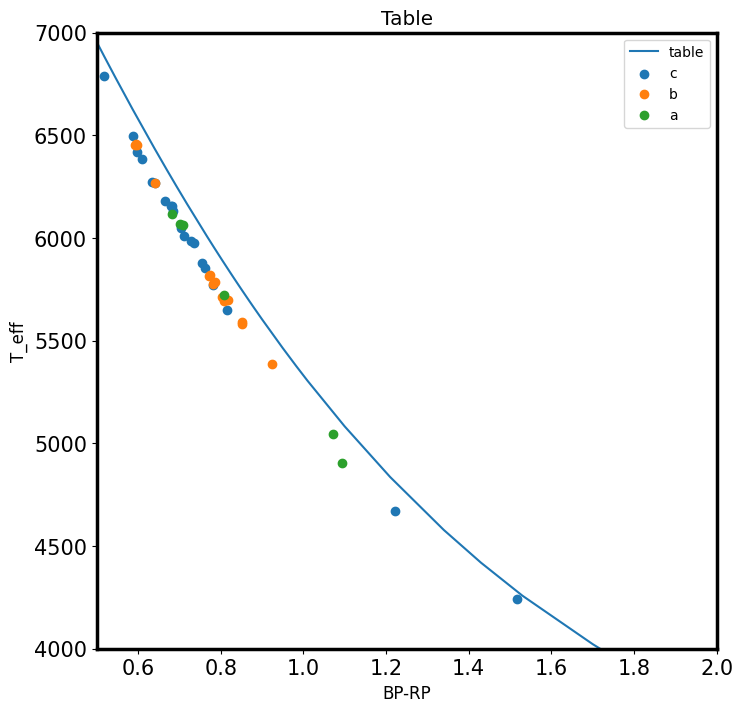

In [32]:
### Make a nice canvas for the figure
figure, axis = plt.subplots(figsize=(8,8))

### Add the data
mask = table['BpRp'] <= 4.0
filtered = table[mask]
spl = make_smoothing_spline(filtered['BpRp'], filtered['Teff'], lam=0.5)
#y_smooth = gaussian_filter1d(table['Teff'], sigma=1)

axis.plot(filtered['BpRp'],spl(filtered['BpRp']),label='table') 
#axis.plot(table['BpRp'],table['Teff'],label='Table')
axis.scatter(best_matchc['BP-RP'],best_matchc['Teff'],label='c')

axis.scatter(best_matchb['BP-RP'],best_matchb['Teff'],label='b')
axis.scatter(best_matcha['BP-RP'],best_matcha['Teff'],label='a')

### Set the x and y limits
axis.set_xlim(0.5,2) # after you plot the full sample, choose a minimum and maximum BP-RP and activate this line
axis.set_ylim(4000,7000) # same but for Gmag; recall that bright stars go on top and faint stars go on the bottom of a CMD

### Add axis labels
axis.set_xlabel('BP-RP',fontsize='large') # Add axis labels. you can use the fontsize= keyword to change the font size.
axis.set_ylabel('T_eff',fontsize='large')

### Add title
axis.set_title('Table',fontsize='x-large') # Add a title.

# Make plot look nice
axis_border_width = 2.5
fontsize_axis_labels = 15
axis.tick_params(axis='both', which='major', labelsize=fontsize_axis_labels)
axis.spines['top'].set_linewidth(axis_border_width)
axis.spines['left'].set_linewidth(axis_border_width)
axis.spines['right'].set_linewidth(axis_border_width)
axis.spines['bottom'].set_linewidth(axis_border_width)
axis.legend()

# Conclude the figure
figure.show()

In [33]:
print(filtered['Teff'])
print(filtered['BpRp'])

[10700 10400  9700  9300  8800  8600  8250  8100  7910  7760  7590  7400
  7220  7020  6820  6750  6670  6550  6350  6280  6180  6050  5990  5930
  5860  5770  5720  5680  5660  5600  5550  5480  5380  5270  5170  5100
  4830  4600  4440  4300  4100  3990  3930  3850  3770  3660  3620  3560
  3470  3430  3270  3210  3110  3060  2930]
[-0.12  -0.087 -0.037  0.005  0.068  0.11   0.166  0.194  0.222  0.263
  0.32   0.327  0.377  0.434  0.49   0.518  0.546  0.587  0.64   0.67
  0.694  0.719  0.767  0.784  0.803  0.823  0.832  0.841  0.85   0.869
  0.88   0.9    0.95   0.983  1.01   1.1    1.21   1.34   1.43   1.53
  1.7    1.73   1.79   1.84   1.97   2.09   2.13   2.23   2.39   2.5
  2.78   2.94   3.16   3.35   3.71 ]


In [9]:
tablea = Table([unique_result_a["ra"],unique_result_a["dec"]],names=('ra','dec'))
tableb = Table([unique_result_b["ra"],unique_result_b["dec"]],names=('ra','dec'))
tablec = Table([unique_result_c["ra"],unique_result_c["dec"]],names=('ra','dec'))

search_radius_CB = 5
table2massa = XMatch.query(cat1=tablea,
                            cat2='vizier:II/281/2mass6x',
                            max_distance=search_radius_CB * units.arcsec,
                            colRA1='ra', colDec1='dec')
table2massb = XMatch.query(cat1=tableb,
                            cat2='vizier:II/281/2mass6x',
                            max_distance=search_radius_CB * units.arcsec,
                            colRA1='ra', colDec1='dec')
table2massc = XMatch.query(cat1=tablec,
                            cat2='vizier:II/281/2mass6x',
                            max_distance=search_radius_CB * units.arcsec,
                            colRA1='ra', colDec1='dec')

KeyError: ''

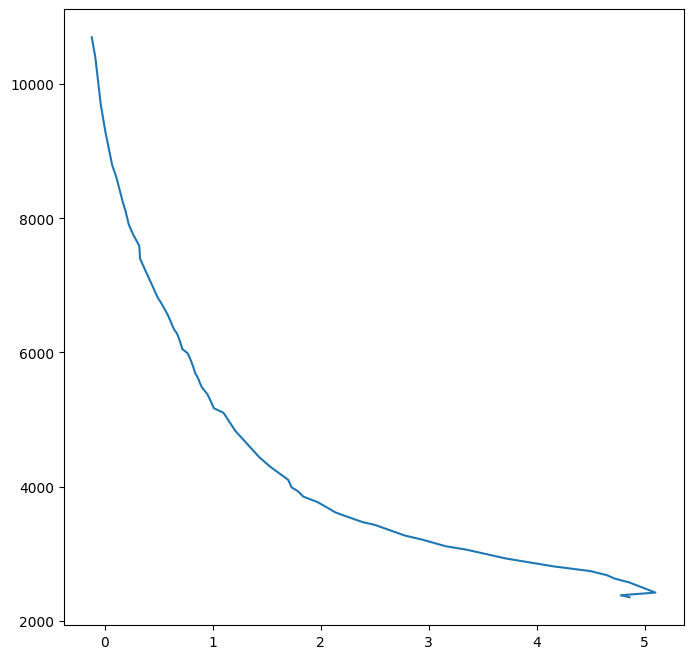

In [36]:
### Make a nice canvas for the figure
figure, axis = plt.subplots(figsize=(8,8))

### Add the data

#spl = make_smoothing_spline(table['Teff'],table['BpRp'], lam=0)
#y_smooth = gaussian_filter1d(table['Teff'], sigma=1)
axis.plot(table['BpRp'],table['Teff'],label='table') 
#axis.scatter(table['BpRp'],table['Teff'],label='Table')
axis.scatter(table2massa['Bmag']-table2massa['Rmag'],table2massa[''],label='c')

axis.scatter(best_matchb['BP-RP'],best_matchb['Teff'],label='b')
axis.scatter(best_matcha['BP-RP'],best_matcha['Teff'],label='a')

### Set the x and y limits
axis.set_xlim(0.5,2) # after you plot the full sample, choose a minimum and maximum BP-RP and activate this line
axis.set_ylim(4000,7000) # same but for Gmag; recall that bright stars go on top and faint stars go on the bottom of a CMD

### Add axis labels
axis.set_xlabel('BP-RP',fontsize='large') # Add axis labels. you can use the fontsize= keyword to change the font size.
axis.set_ylabel('T_eff',fontsize='large')

### Add title
axis.set_title('Table',fontsize='x-large') # Add a title.

# Make plot look nice
axis_border_width = 2.5
fontsize_axis_labels = 15
axis.tick_params(axis='both', which='major', labelsize=fontsize_axis_labels)
axis.spines['top'].set_linewidth(axis_border_width)
axis.spines['left'].set_linewidth(axis_border_width)
axis.spines['right'].set_linewidth(axis_border_width)
axis.spines['bottom'].set_linewidth(axis_border_width)
axis.legend()

# Conclude the figure
figure.show()

In [37]:
table2massa

angDist,ra,dec,2MASS,ra2,dec2,errHalfMaj,errHalfMin,errPosAng,Jmag,Hmag,Kmag,e_Jmag,e_Hmag,e_Kmag,Qflg,Rflg,Xflg,date,gcntr,l,b,Jsig,Hsig,Ksig,Jsnr,Hsnr,Ksnr,USNO-A2.0,Dopt,PAopt,Bmag,Rmag,Nopt,Bflg,Cflg,Aflg,Ndet,cat,rel
arcsec,,,,deg,deg,arcsec,arcsec,deg,mag,mag,mag,mag,mag,mag,,,,d,,deg,deg,mag,mag,mag,,,,,,arcsec,mag,mag,,,,,,,
float64,float64,float64,str16,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,str3,int16,uint8,float64,int32,float64,float64,float32,float32,float32,float32,float32,float32,str13,float32,int16,float32,float32,uint8,int16,str3,uint8,int32,uint8,str1
0.013986,157.6565802735,55.98053880257,10303758+5558499,157.656586,55.980541,0.31,0.3,90.0,4.046,3.729,3.667,0.273,0.223,0.302,DDD,333,0,2451628.6807,38487492,154.291956,51.70265,0.272,0.222,0.302,1000000.0,1000000.0,965206.0,T3819-01373-1,0.06,79,5.3,4.8,2,111,000,0,60606,1,A
0.199044,157.6565802735,55.98053880257,10303755+5558500,157.656489,55.98056,0.31,0.31,0.0,3.875,3.714,3.59,0.317,0.203,0.268,DCD,333,0,2451628.6987,38496312,154.29198,51.702594,0.316,0.202,0.268,1000000.0,1000000.0,1000000.0,T3819-01373-1,0.16,300,5.3,4.8,2,111,000,0,60606,0,A
3.300867,157.6565802735,55.98053880257,10303725+5558518,157.655227,55.981056,0.51,0.51,90.0,9.026,8.469,--,--,--,--,UUZ,9,0,2451628.6807,38487483,154.291956,51.701732,--,--,--,--,--,--,T3819-01373-1,3.27,305,5.3,4.8,2,0,00C,0,6,0,F
3.569578,157.6565802735,55.98053880257,10303799+5558505,157.658325,55.980713,0.15,0.13,25.0,8.971,--,8.174,--,--,--,UZU,90,0,2451628.6987,38496315,154.290845,51.703359,--,--,--,--,--,--,T3819-01373-1,3.61,80,5.3,4.8,2,0,0C0,0,600,0,F
3.67946,157.6565802735,55.98053880257,10303801+5558494,157.658393,55.980412,0.14,0.13,90.0,8.971,--,8.445,--,--,--,UZU,90,0,2451628.6807,38487496,154.291213,51.703559,--,--,--,--,--,--,T3819-01373-1,3.72,97,5.3,4.8,2,0,0C0,0,500,0,F
3.806059,157.6565802735,55.98053880257,10303762+5558537,157.656782,55.98159,0.23,0.13,21.0,8.964,8.499,--,--,--,--,UUZ,9,0,2451628.6807,38487472,154.290455,51.702152,--,--,--,--,--,--,T3819-01373-1,3.81,7,5.3,4.8,2,0,00C,0,6,0,F
3.837905,157.6565802735,55.98053880257,10303713+5558508,157.654725,55.980782,0.14,0.13,90.0,8.968,--,8.414,--,--,--,UZU,90,0,2451628.6807,38487485,154.292576,51.701653,--,--,--,--,--,--,T3819-01373-1,3.8,283,5.3,4.8,2,0,0C0,0,600,0,F
4.035882,157.6565802735,55.98053880257,10303763+5558459,157.656792,55.979424,0.15,0.13,126.0,8.967,8.531,--,--,--,--,UUZ,9,0,2451628.6807,38487512,154.293344,51.703372,--,--,--,--,--,--,T3819-01373-1,4.03,173,5.3,4.8,2,0,00C,0,6,0,F


In [38]:
unique_result_a

main_id,ra,dec,coo_err_maj,coo_err_min,coo_err_angle,coo_wavelength,coo_bibcode,mesplx.bibcode,mesplx.mespos,mesplx.obscode,mesplx.plx,mesplx.plx_err,mesplx.plx_prec,B,F150W,F200W,F444W,g,G,H,i,I,J,K,r,R,u,U,V,z,mesfe_h.bibcode,mesfe_h.catno,mesfe_h.compstar,mesfe_h.fe_h,mesfe_h.fe_h_prec,mesfe_h.flag,mesfe_h.log_g,mesfe_h.log_g_prec,mesfe_h.mespos,mesfe_h.teff,user_specified_id,object_number_id
,deg,deg,mas,mas,deg,,,,,,mas,mas,,,,,,,,,,,,,,,,,,,,,,,,,cm/s**2,,,unit-degK,,
object,float64,float64,float32,float32,int16,str1,object,object,int16,object,float32,float32,int16,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object,object,float32,int16,str1,float32,int16,int16,int32,object,int64
,--,--,--,--,--,,,,--,,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,,,,--,--,,--,--,--,--,HD 100623 A,23
* 6 Cet,2.81607516478,-15.467977907889997,0.0946,0.0694,90,O,2020yCat.1350....0G,1997A&A...323L..49P,1,,52.94,0.77,2,5.380000114440918,--,--,--,--,4.7636189460754395,3.680000066757202,--,--,3.940000057220459,3.630000114440918,--,--,--,5.349999904632568,4.889999866485596,--,1984Msngr..38...33E,F433,SUN,-0.34,2,,4.1,1,35,6300,HD 693,47
* 12 Oph,249.08937370706997,-2.3245869511758324,0.0357,0.0165,90,O,2020yCat.1350....0G,1997A&A...323L..49P,1,,102.27,0.85,2,6.550000190734863,--,--,--,--,5.553552150726318,3.880000114440918,--,4.739999771118164,4.329999923706055,3.8299999237060547,--,5.130000114440918,--,7.0,5.769999980926514,--,2015A&A...579A..20M,,,--,--,,4.69,2,42,5306,HD 149661,12
* 18 Sco,243.90529281485533,-8.369439479286111,0.0659,0.0548,90,O,2020yCat.1350....0G,2007A&A...474..653V,5,,71.94,0.37,2,6.150000095367432,--,--,--,--,5.327651023864746,4.1620001792907715,--,--,4.666999816894531,4.190000057220459,--,--,--,--,5.5,--,2004A&A...427..933K,,,--,--,,--,--,65,5799,HD 146233,14
* 36 UMa,157.6565802735,55.98053880257,0.0484,0.0622,90,O,2020yCat.1350....0G,1997A&A...323L..49P,1,,77.82,0.65,2,--,--,--,--,--,4.673892021179199,3.757999897003174,--,--,4.0329999923706055,3.6440000534057617,--,4.5,--,--,--,--,2013ApJ...771...40B,,,--,--,,--,--,14,6203,HD 90839,25
* 47 UMa,164.86655313083833,40.430255714645554,0.0627,0.0799,90,O,2020yCat.1350....0G,2007A&A...474..653V,5,,71.11,0.25,2,5.659999847412109,--,--,--,--,4.866588115692139,3.740000009536743,--,--,3.9600000381469727,3.75,--,4.699999809265137,--,--,--,--,1974A&A....36..191H,F229,SUN,-0.02,2,,4.31,2,78,5860,HD 95128,24
* 61 Cyg A,316.7247482895925,38.74941731943694,0.0388,0.0485,90,O,2020yCat.1350....0G,2007A&A...474..653V,4,,286.82,6.78,2,6.389999866485596,--,--,--,--,4.7667131423950195,2.5,--,3.5399999618530273,3.119999885559082,2.680000066757202,--,4.190000057220459,--,7.5,5.210000038146973,--,1998MNRAS.299..753Z,,SUN,-0.3,2,,4.8,2,18,4450,HD 201091,7
* 61 Cyg B,316.7302660185276,38.74204403329556,0.019,0.0232,90,O,2020yCat.1350....0G,2007A&A...474..653V,4,,285.88,0.54,2,7.400000095367432,--,--,--,--,5.4506449699401855,2.859999895095825,--,3.549999952316284,3.549999952316284,2.319999933242798,--,4.860000133514404,--,8.630000114440918,6.03000020980835,--,1974ApJS...27..405O,F237,SUN,-0.65,2,,4.6,1,42,3652,HD 201092,6


In [39]:
search_radius_CB = 5
table2mass = XMatch.query(cat1=table2,
                            cat2='vizier:II/281/2mass6x',
                            max_distance=search_radius_CB * units.arcsec,
                            colRA1='ra', colDec1='dec')
table2mass

angDist,ra,dec,2MASS,ra2,dec2,errHalfMaj,errHalfMin,errPosAng,Jmag,Hmag,Kmag,e_Jmag,e_Hmag,e_Kmag,Qflg,Rflg,Xflg,date,gcntr,l,b,Jsig,Hsig,Ksig,Jsnr,Hsnr,Ksnr,USNO-A2.0,Dopt,PAopt,Bmag,Rmag,Nopt,Bflg,Cflg,Aflg,Ndet,cat,rel
arcsec,,,,deg,deg,arcsec,arcsec,deg,mag,mag,mag,mag,mag,mag,,,,d,,deg,deg,mag,mag,mag,,,,,,arcsec,mag,mag,,,,,,,
float64,float64,float64,str16,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,str3,int16,uint8,float64,int32,float64,float64,float32,float32,float32,float32,float32,float32,str13,float32,int16,float32,float32,uint8,int16,str3,uint8,int32,uint8,str1
0.013986,157.6565802735,55.98053880257,10303758+5558499,157.656586,55.980541,0.31,0.3,90.0,4.046,3.729,3.667,0.273,0.223,0.302,DDD,333,0,2451628.6807,38487492,154.291956,51.70265,0.272,0.222,0.302,1000000.0,1000000.0,965206.0,T3819-01373-1,0.06,79,5.3,4.8,2,111,000,0,60606,1,A
0.199044,157.6565802735,55.98053880257,10303755+5558500,157.656489,55.98056,0.31,0.31,0.0,3.875,3.714,3.59,0.317,0.203,0.268,DCD,333,0,2451628.6987,38496312,154.29198,51.702594,0.316,0.202,0.268,1000000.0,1000000.0,1000000.0,T3819-01373-1,0.16,300,5.3,4.8,2,111,000,0,60606,0,A
3.300867,157.6565802735,55.98053880257,10303725+5558518,157.655227,55.981056,0.51,0.51,90.0,9.026,8.469,--,--,--,--,UUZ,9,0,2451628.6807,38487483,154.291956,51.701732,--,--,--,--,--,--,T3819-01373-1,3.27,305,5.3,4.8,2,0,00C,0,6,0,F
3.569578,157.6565802735,55.98053880257,10303799+5558505,157.658325,55.980713,0.15,0.13,25.0,8.971,--,8.174,--,--,--,UZU,90,0,2451628.6987,38496315,154.290845,51.703359,--,--,--,--,--,--,T3819-01373-1,3.61,80,5.3,4.8,2,0,0C0,0,600,0,F
3.67946,157.6565802735,55.98053880257,10303801+5558494,157.658393,55.980412,0.14,0.13,90.0,8.971,--,8.445,--,--,--,UZU,90,0,2451628.6807,38487496,154.291213,51.703559,--,--,--,--,--,--,T3819-01373-1,3.72,97,5.3,4.8,2,0,0C0,0,500,0,F
3.806059,157.6565802735,55.98053880257,10303762+5558537,157.656782,55.98159,0.23,0.13,21.0,8.964,8.499,--,--,--,--,UUZ,9,0,2451628.6807,38487472,154.290455,51.702152,--,--,--,--,--,--,T3819-01373-1,3.81,7,5.3,4.8,2,0,00C,0,6,0,F
3.837905,157.6565802735,55.98053880257,10303713+5558508,157.654725,55.980782,0.14,0.13,90.0,8.968,--,8.414,--,--,--,UZU,90,0,2451628.6807,38487485,154.292576,51.701653,--,--,--,--,--,--,T3819-01373-1,3.8,283,5.3,4.8,2,0,0C0,0,600,0,F
4.035882,157.6565802735,55.98053880257,10303763+5558459,157.656792,55.979424,0.15,0.13,126.0,8.967,8.531,--,--,--,--,UUZ,9,0,2451628.6807,38487512,154.293344,51.703372,--,--,--,--,--,--,T3819-01373-1,4.03,173,5.3,4.8,2,0,00C,0,6,0,F


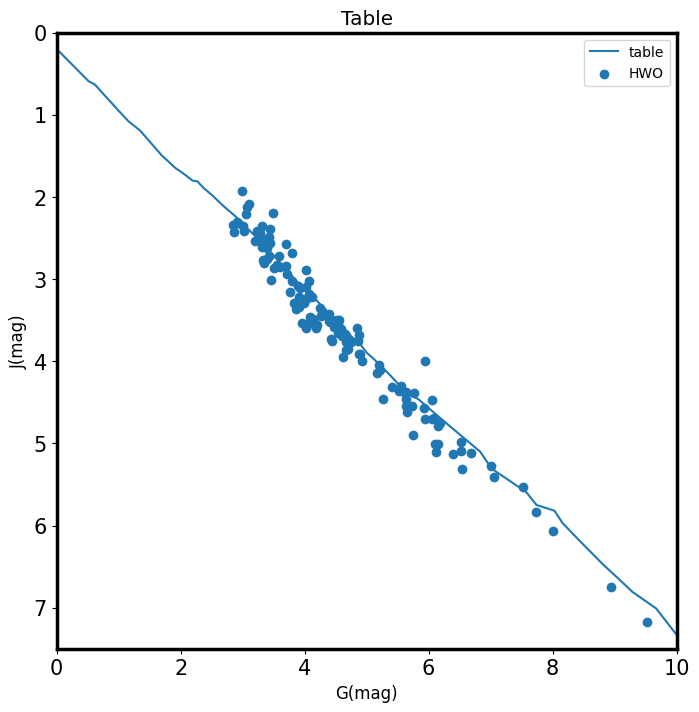

In [ ]:
### Make a nice canvas for the figure
figure, axis = plt.subplots(figsize=(8,8))

### Add the data

#spl = make_smoothing_spline(table['Teff'],table['BpRp'], lam=0)
#y_smooth = gaussian_filter1d(table['Teff'], sigma=1)
axis.plot(table['M_G'],table['M_J'],label='table') 
#axis.scatter(table['BpRp'],table['Teff'],label='Table')
axis.scatter(unique_result['G']-5*np.log10(1000/unique_result['mesplx.plx'])+5,unique_result['J']-5*np.log10(1000/unique_result['mesplx.plx'])+5,label='HWO')

### Set the x and y limits
axis.set_xlim(0,10) # after you plot the full sample, choose a minimum and maximum BP-RP and activate this line
axis.set_ylim(7.5,0) # same but for Gmag; recall that bright stars go on top and faint stars go on the bottom of a CMD

### Add axis labels
axis.set_xlabel('G(mag)',fontsize='large') # Add axis labels. you can use the fontsize= keyword to change the font size.
axis.set_ylabel('J(mag)',fontsize='large')

### Add title
axis.set_title('Table',fontsize='x-large') # Add a title.

# Make plot look nice
axis_border_width = 2.5
fontsize_axis_labels = 15
axis.tick_params(axis='both', which='major', labelsize=fontsize_axis_labels)
axis.spines['top'].set_linewidth(axis_border_width)
axis.spines['left'].set_linewidth(axis_border_width)
axis.spines['right'].set_linewidth(axis_border_width)
axis.spines['bottom'].set_linewidth(axis_border_width)
axis.legend()

# Conclude the figure
figure.show()

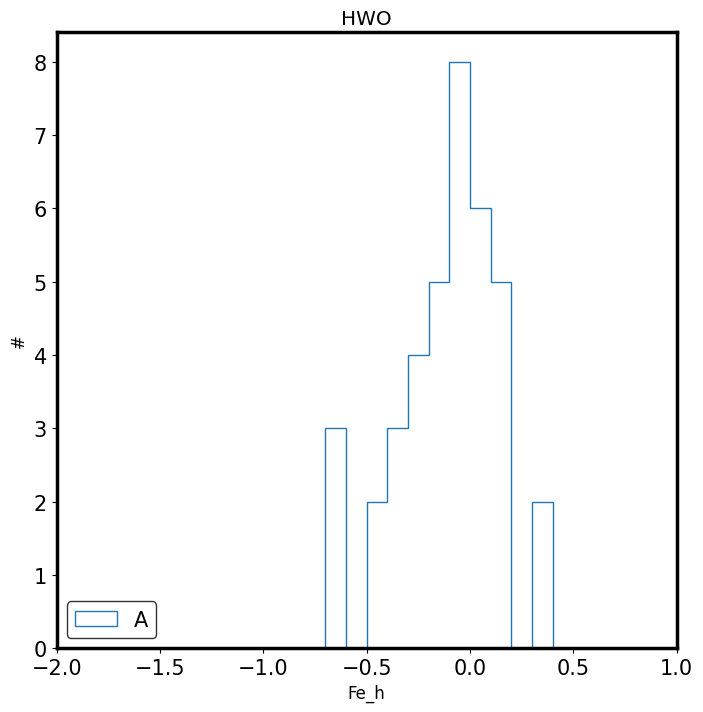

In [ ]:
### Make a nice canvas for the figure
figure, axis = plt.subplots(figsize=(8,8))

### Add the data
#axis.hist(unique_result['mesfe_h.fe_h'],label='All',histtype='step')
axis.hist(unique_result_a['mesfe_h.fe_h'],label='A',bins=np.arange(-2,8,0.1),histtype='step')
#axis.hist(unique_result_b['mesfe_h.fe_h'],label='B',bins=np.arange(-2,8,0.1),histtype='step')
#axis.hist(unique_result_c['mesfe_h.fe_h'],label='C',bins=np.arange(-2,8,0.1),histtype='step')

axis.legend(loc='lower left', fontsize=15, edgecolor='black')

### Set the x and y limits # after you plot the full sample, choose a minimum and maximum BP-RP and activate this line
#axis.set_ylim(0,45) # same but for Gmag; recall that bright stars go on top and faint stars go on the bottom of a CMD
axis.set_xlim(-2,1)
### Add axis labels
axis.set_xlabel('Fe_h',fontsize='large') # Add axis labels. you can use the fontsize= keyword to change the font size.
axis.set_ylabel('#',fontsize='large')

### Add title
axis.set_title('HWO',fontsize='x-large') # Add a title.

# Make plot look nice
axis_border_width = 2.5
fontsize_axis_labels = 15
axis.tick_params(axis='both', which='major', labelsize=fontsize_axis_labels)
axis.spines['top'].set_linewidth(axis_border_width)
axis.spines['left'].set_linewidth(axis_border_width)
axis.spines['right'].set_linewidth(axis_border_width)
axis.spines['bottom'].set_linewidth(axis_border_width)

figure.show()

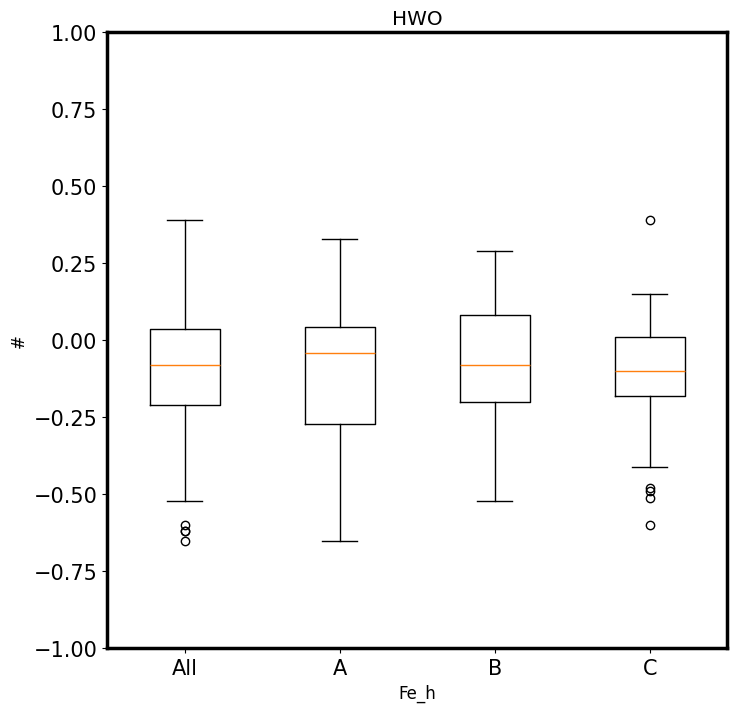

In [ ]:
### Make a nice canvas for the figure
figure, axis = plt.subplots(figsize=(8,8))

### Add the data
fe_h=[unique_result['mesfe_h.fe_h'],unique_result_a['mesfe_h.fe_h'],unique_result_b['mesfe_h.fe_h'],unique_result_c['mesfe_h.fe_h']]
axis.boxplot(fe_h,tick_labels=['All','A','B','C'])

### Set the x and y limits # after you plot the full sample, choose a minimum and maximum BP-RP and activate this line
axis.set_ylim(-1,1) # same but for Gmag; recall that bright stars go on top and faint stars go on the bottom of a CMD

### Add axis labels
axis.set_xlabel('Fe_h',fontsize='large') # Add axis labels. you can use the fontsize= keyword to change the font size.
axis.set_ylabel('#',fontsize='large')

### Add title
axis.set_title('HWO',fontsize='x-large') # Add a title.

# Make plot look nice
axis_border_width = 2.5
fontsize_axis_labels = 15
axis.tick_params(axis='both', which='major', labelsize=fontsize_axis_labels)
axis.spines['top'].set_linewidth(axis_border_width)
axis.spines['left'].set_linewidth(axis_border_width)
axis.spines['right'].set_linewidth(axis_border_width)
axis.spines['bottom'].set_linewidth(axis_border_width)

figure.show()

In [ ]:
print(max(unique_result['mesfe_h.fe_h']))

--


In [ ]:
test = Simbad.query_object("HIP 54035 ")

In [ ]:
print(test['main_id'])

 main_id 
---------
HD  95735
HD  95735
HD  95735
HD  95735
HD  95735
HD  95735
HD  95735
HD  95735
HD  95735
HD  95735
      ...
HD  95735
HD  95735
HD  95735
HD  95735
HD  95735
HD  95735
HD  95735
HD  95735
HD  95735
HD  95735
Length = 260 rows


In [40]:
from astropy.table import Table
rotation_data = np.load("rotation_periods.npy")
rotation_table = Table(
    rotation_data,
    names=("RA", "DE", "rotation_period")
)

In [ ]:
Vizier.ROW_LIMIT=-1

rot = Vizier.get_catalogs("J/ApJS/258/16")[0]

In [ ]:
rot

TIC,m_TIC,RAJ2000,DEJ2000,pmRA,pmDE,Tmag,BJD0,e_BJD0,Per,e_Per,Morph,Wp-pf,Dp-pf,Phip-pf,Ws-pf,Ds-pf,Phis-pf,Wp-2g,Dp-2g,Phip-2g,Ws-2g,Ds-2g,Phis-2g,TESSebs,Simbad
,,deg,deg,mas / yr,mas / yr,mag,d,d,d,d,,,,,,,,,,,,,,,
str10,uint8,float64,float64,float64,float64,float32,float64,float64,float64,float64,float32,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,str7,str6
0185259483,1,175.1082987591,-6.1025301959,5.765,-10.347,10.918,1544.164633,2.11174e-05,0.3105640,1.408292e-07,0.837,0.127,0.098,0.682,--,--,--,0.32,0.219,0.00422,--,--,--,TESSebs,Simbad
0307990280,1,129.2359834347,-67.7447505240,-22.880,-12.314,9.431,1546.118024,0.0325356,2.3159117,3.040787e-05,0.932,0.305,0.036,1,0.267,0.023,0.515,--,--,--,--,--,--,TESSebs,Simbad
0387178621,1,140.4140519781,-55.9076768445,-4.222,4.224,11.145,1548.193069,0.00598825,8.1871258,4.664703e-05,0.545,0.071,0.271,1,--,--,--,0.141,0.441,9.46e-05,0.177,0.071,0.506,TESSebs,Simbad
0300560295,1,112.9159873676,-68.1332134683,-20.414,9.187,10.776,1603.567276,0.0013868,20.5887760,6.24271e-05,0.044,0.004,0.027,1,0.004,0.026,0.500,0.00621,0.030,0.000426,0.006,0.029,0.5,TESSebs,Simbad
0318185328,1,162.1417983388,-3.6244953157,51.800,-44.010,10.410,1544.643095,0.00312015,0.3683055,1.60452e-06,0.745,0.098,0.094,1.01,--,--,--,0.362,0.300,0.00311,0.303,0.243,0.503,TESSebs,Simbad
0363326796,1,146.0981967995,-48.8373107729,-43.221,17.830,9.835,1553.843475,0.00015481,11.3956206,0.0002371016,0.160,0.018,0.067,1,--,--,--,0.0289,0.087,1,0.038,0.006,0.5,TESSebs,Simbad
0073764693,1,155.8412284988,-37.6166400555,-33.259,-20.126,11.777,1544.388542,0.0023394,0.1392960,2.635568e-05,0.657,--,--,--,--,--,--,--,--,--,--,--,--,TESSebs,Simbad
0031273263,1,88.1036912820,-68.1595542749,5.418,26.235,10.786,1337.915766,0.0535014,22.5729583,0.001002191,0.081,0.012,0.140,1,--,--,--,0.0193,0.220,1.9e-05,--,--,--,TESSebs,Simbad


In [ ]:
table2

ra,dec
deg,deg
float64,float64
--,--
2.81607516478,-15.467977907889997
191.24752068427662,39.27891614786027
54.21826543507,0.40166447161916674
249.08937370706997,-2.3245869511758324
147.14738061867,46.02100739317
296.6066668696129,33.72759820378805
243.90529281485533,-8.369439479286111


In [11]:
arc_table = Table.read("TSS_ARC.csv", format="csv")

small_arc_table = arc_table["star_name", "ra", "dec", "Age", "prot_adopt"]


small_arc_table.rename_column("prot_adopt", "rotation_period")

small_arc_table["ra"].unit = units.deg
small_arc_table["dec"].unit = units.deg
small_arc_table["rotation_period"].unit = units.day
small_arc_table["Age"].unit = units.Myr

small_arc_table

star_name,ra,dec,Age,rotation_period
,deg,deg,Myr,d
str28,float64,float64,float64,float64
TIC 114807654,0.00434642638,-19.49883024682,--,--
GAIA DR3 2875125810310195712,0.0170125,34.1885535,8.57,--
TIC 138662501,0.05285038405,-4.05367997341,--,5.8133
TIC 290405947,0.11312831757,-79.06198229236,3.766,10.6836
TIC 201236480,0.1349923995,-56.83560083708,6.07,21.8699
TIC 138667728,0.14495192033,-5.55205158157,--,--
TIC 380157588,0.16354821963,18.48885328649,--,--
TIC 267083739,0.16800036666,-69.67596567438,--,8.148017


In [12]:
search_radius_CB = 5
rottable = XMatch.query(cat1=table2,
                            cat2=small_arc_table,
                            max_distance=search_radius_CB * units.arcsec,
                            colRA1='ra', colDec1='dec',
                            colRA2='ra', colDec2='dec'
                            )
rottablea = XMatch.query(cat1=table2a,
                            cat2=small_arc_table,
                            max_distance=search_radius_CB * units.arcsec,
                            colRA1='ra', colDec1='dec',
                            colRA2='ra', colDec2='dec'
                            )
rottableb = XMatch.query(cat1=table2b,
                            cat2=small_arc_table,
                            max_distance=search_radius_CB * units.arcsec,
                            colRA1='ra', colDec1='dec',
                            colRA2='ra', colDec2='dec'
                            )
rottablec = XMatch.query(cat1=table2c,
                            cat2=small_arc_table,
                            max_distance=search_radius_CB * units.arcsec,
                            colRA1='ra', colDec1='dec',
                            colRA2='ra', colDec2='dec'
                            )
#rottable
rottable_with_periods = rottable[
    ~rottable["rotation_period"].mask
]


rottable_with_ages = rottable[
    ~rottable["Age"].mask
]

rottable_with_both = rottable[
    ~rottable["rotation_period"].mask & ~rottable["Age"].mask
]
rottable_with_botha = rottablea[
    ~rottablea["rotation_period"].mask & ~rottablea["Age"].mask
]
rottable_with_bothb = rottableb[
    ~rottableb["rotation_period"].mask & ~rottableb["Age"].mask
]
rottable_with_bothc = rottablec[
    ~rottablec["rotation_period"].mask & ~rottablec["Age"].mask
]

#rottable_with_periods

In [13]:
#rottable_with_ages
rottable_with_both

angDist,ra,dec,star_name,ra2,dec2,Age,rotation_period
arcsec,,,,,,,
float64,float64,float64,str28,float64,float64,float32,float64
0.105207,2.81607516478,-15.467977907889997,TIC 289673491,2.81604541137,-15.46798354267,3.859,5.200395
0.006021,249.08937370706997,-2.3245869511758324,TIC 58092025,249.08937204273,-2.32458677361,12.081,21.07
0.007169,147.14738061867,46.02100739317,TIC 23969522,147.14738042288,46.02100937978,7.819,4.296
0.011333,296.6066668696129,33.72759820378805,TIC 58445695,296.60666573585,33.72759520021,3.236,3.186301
0.001474,243.90529281485533,-8.369439479286111,TIC 135656809,243.90529322864,-8.36943947035,9.946,22.7
0.008443,112.48315488244,49.67245940035,TIC 328324648,112.4831534377,49.67246155111,3.311,2.209643
0.000501,273.4743033607241,64.39728493338667,TIC 233121747,273.47430328637,64.39728479784,2.815,4.293302
4.858517,258.8365985355513,-26.601699224429723,TIC 1277142190,258.83743593135,-26.60282206323,6.304,21.11


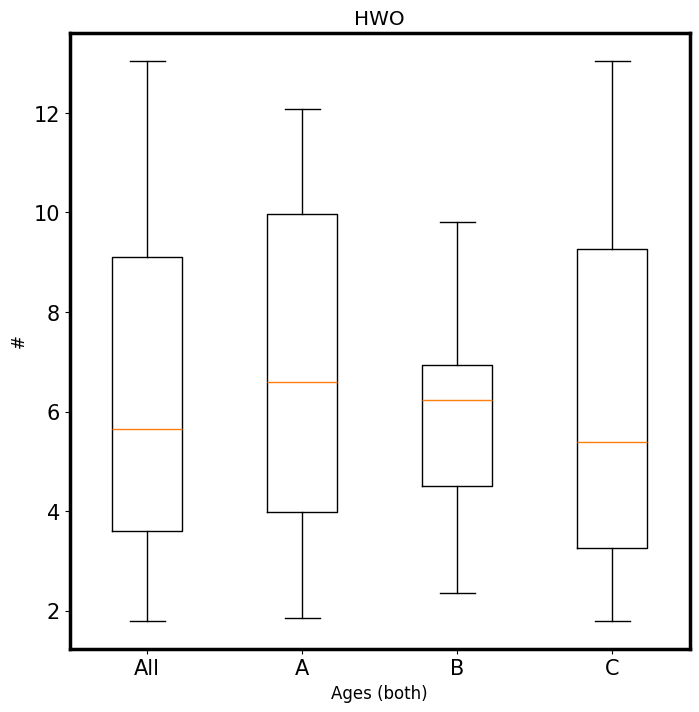

In [ ]:
### Make a nice canvas for the figure
figure, axis = plt.subplots(figsize=(8,8))

### Add the data
ages=[rottable_with_both['Age'],rottable_with_botha['Age'],rottable_with_bothb['Age'],rottable_with_bothc['Age']]
axis.boxplot(ages,tick_labels=['All','A','B','C'])

### Set the x and y limits # after you plot the full sample, choose a minimum and maximum BP-RP and activate this line
#axis.set_ylim(-2,2) # same but for Gmag; recall that bright stars go on top and faint stars go on the bottom of a CMD

### Add axis labels
axis.set_xlabel('Ages (both)',fontsize='large') # Add axis labels. you can use the fontsize= keyword to change the font size.
axis.set_ylabel('#',fontsize='large')

### Add title
axis.set_title('HWO',fontsize='x-large') # Add a title.

# Make plot look nice
axis_border_width = 2.5
fontsize_axis_labels = 15
axis.tick_params(axis='both', which='major', labelsize=fontsize_axis_labels)
axis.spines['top'].set_linewidth(axis_border_width)
axis.spines['left'].set_linewidth(axis_border_width)
axis.spines['right'].set_linewidth(axis_border_width)
axis.spines['bottom'].set_linewidth(axis_border_width)

figure.show()

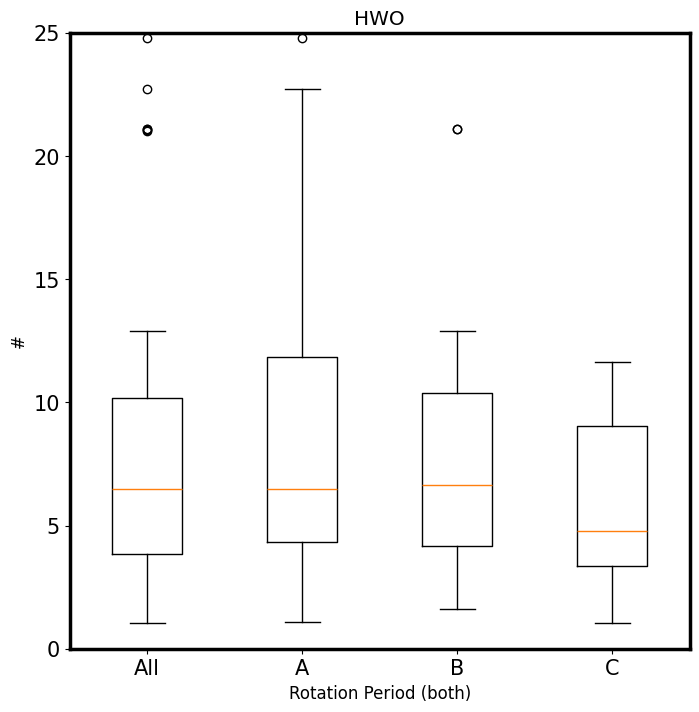

In [ ]:
### Make a nice canvas for the figure
figure, axis = plt.subplots(figsize=(8,8))

### Add the data
rotation_periods=[rottable['rotation_period'],rottablea['rotation_period'],rottableb['rotation_period'],rottablec['rotation_period']]
axis.boxplot(rotation_periods,tick_labels=['All','A','B','C'])

### Set the x and y limits # after you plot the full sample, choose a minimum and maximum BP-RP and activate this line
axis.set_ylim(0,25) # same but for Gmag; recall that bright stars go on top and faint stars go on the bottom of a CMD

### Add axis labels
axis.set_xlabel('Rotation Period (both)',fontsize='large') # Add axis labels. you can use the fontsize= keyword to change the font size.
axis.set_ylabel('#',fontsize='large')

### Add title
axis.set_title('HWO',fontsize='x-large') # Add a title.

# Make plot look nice
axis_border_width = 2.5
fontsize_axis_labels = 15
axis.tick_params(axis='both', which='major', labelsize=fontsize_axis_labels)
axis.spines['top'].set_linewidth(axis_border_width)
axis.spines['left'].set_linewidth(axis_border_width)
axis.spines['right'].set_linewidth(axis_border_width)
axis.spines['bottom'].set_linewidth(axis_border_width)

figure.show()

In [15]:
from astroquery.mast import Catalogs

tic = Catalogs.query_criteria(
    catalog="TIC",
    ID= 289673491  # Replace with your TIC ID
)

print(tic['mass'])

mass
----
1.19


In [16]:
from astroquery.mast import Catalogs
from astropy.coordinates import SkyCoord

star_ages = []
masses = []
rotation_periods = []
names = []

for i, star in enumerate(rottable_with_both):
    name = star["star_name"]
    coord = SkyCoord(star["ra"], star["dec"], unit="deg")

    tic_matches = Catalogs.query_region(
        coord,
        catalog="TIC",
        radius=5 * units.arcsec
    )

    if len(tic_matches) > 0:
        if "dstArcSec" in tic_matches.colnames:
            tic_matches.sort("dstArcSec")

        tic_id = int(tic_matches[0]["ID"])
        tic = Catalogs.query_criteria(
            catalog="TIC",
            ID=tic_id
        )

        if len(tic) > 0 and "mass" in tic.colnames:
            mass = tic[0]["mass"]
        else:
            mass = np.nan
    else:
        mass = np.nan

    star_ages.append(star["Age"])
    masses.append(mass)
    rotation_periods.append(star["rotation_period"])
    names.append(name)

    print(f"{i + 1}/{len(rottable_with_both)} {name}: mass = {mass}")

mass_table = Table(
    [star_ages, masses, rotation_periods, names],
    names=("star_age", "mass", "rotation_period", "name")
)

mass_table

1/70 TIC 289673491: mass = 1.19
2/70 TIC 58092025: mass = 0.91
3/70 TIC 23969522: mass = 1.06
4/70 TIC 58445695: mass = 1.22
5/70 TIC 135656809: mass = 1.04
6/70 TIC 328324648: mass = 1.26
7/70 TIC 233121747: mass = 1.32
8/70 TIC 1277142190: mass = nan
9/70 TIC 1277142190: mass = 0.87
10/70 TIC 416519065: mass = 1.18
11/70 TIC 95431211: mass = 1.31
12/70 TIC 21535479: mass = 1.06
13/70 TIC 117979951: mass = 1.05
14/70 TIC 101641846: mass = 0.97
15/70 TIC 46125330: mass = 1.35
16/70 TIC 47346402: mass = 1.16
17/70 TIC 150796339: mass = 1.34
18/70 TIC 447823435: mass = 1.16
19/70 TIC 88523071: mass = 1.18
20/70 TIC 458445966: mass = 1.07
21/70 TIC 445070560: mass = 1.1
22/70 TIC 366661076: mass = 1.13
23/70 TIC 229902025: mass = 1.34
24/70 TIC 302188141: mass = 1.22
25/70 TIC 157364190: mass = 1.04
26/70 TIC 118572803: mass = 0.85
27/70 TIC 231698181: mass = 0.73
28/70 TIC 445258206: mass = nan
29/70 TIC 1628071: mass = 1.48
30/70 TIC 93280676: mass = 1.22
31/70 TIC 265488188: mass = 1.1

star_age,mass,rotation_period,name
float32,float64,float64,str14
3.859,1.19,5.200395,TIC 289673491
12.081,0.91,21.07,TIC 58092025
7.819,1.06,4.296,TIC 23969522
3.236,1.22,3.186301,TIC 58445695
9.946,1.04,22.7,TIC 135656809
3.311,1.26,2.209643,TIC 328324648
2.815,1.32,4.293302,TIC 233121747
6.304,nan,21.11,TIC 1277142190
6.304,0.87,21.11,TIC 1277142190


In [17]:
Simbad.reset_votable_fields()
Simbad.add_votable_fields("mesFe_h")

fe_h_values = []

for i, name in enumerate(mass_table["name"]):
    simbad_result = Simbad.query_object(name)

    if simbad_result is not None and len(simbad_result) > 0 and "mesfe_h.fe_h" in simbad_result.colnames:
        fe_h = simbad_result[0]["mesfe_h.fe_h"]
        if np.ma.is_masked(fe_h):
            fe_h = np.nan
    else:
        fe_h = np.nan

    fe_h_values.append(fe_h)
    print(f"{i + 1}/{len(mass_table)} {name}: fe_h = {fe_h}")

mass_table2 = mass_table.copy()
mass_table2["fe_h"] = fe_h_values

mass_table2

1/70 TIC 289673491: fe_h = -0.3400000035762787
2/70 TIC 58092025: fe_h = nan
3/70 TIC 23969522: fe_h = 0.09000000357627869
4/70 TIC 58445695: fe_h = 0.009999999776482582
5/70 TIC 135656809: fe_h = nan
6/70 TIC 328324648: fe_h = -0.28999999165534973
7/70 TIC 233121747: fe_h = -0.17000000178813934
8/70 TIC 1277142190: fe_h = -0.009999999776482582
9/70 TIC 1277142190: fe_h = -0.009999999776482582
10/70 TIC 416519065: fe_h = nan
11/70 TIC 95431211: fe_h = -0.019999999552965164
12/70 TIC 21535479: fe_h = -0.019999999552965164
13/70 TIC 117979951: fe_h = nan
14/70 TIC 101641846: fe_h = nan
15/70 TIC 46125330: fe_h = 0.05999999865889549
16/70 TIC 47346402: fe_h = 0.009999999776482582
17/70 TIC 150796339: fe_h = nan
18/70 TIC 447823435: fe_h = -0.6000000238418579
19/70 TIC 88523071: fe_h = -0.18000000715255737
20/70 TIC 458445966: fe_h = nan
21/70 TIC 445070560: fe_h = 0.18000000715255737
22/70 TIC 366661076: fe_h = nan
23/70 TIC 229902025: fe_h = 0.18000000715255737
24/70 TIC 302188141: fe_h 

star_age,mass,rotation_period,name,fe_h
float32,float64,float64,str14,float64
3.859,1.19,5.200395,TIC 289673491,-0.3400000035762787
12.081,0.91,21.07,TIC 58092025,nan
7.819,1.06,4.296,TIC 23969522,0.09000000357627869
3.236,1.22,3.186301,TIC 58445695,0.009999999776482582
9.946,1.04,22.7,TIC 135656809,nan
3.311,1.26,2.209643,TIC 328324648,-0.28999999165534973
2.815,1.32,4.293302,TIC 233121747,-0.17000000178813934
6.304,nan,21.11,TIC 1277142190,-0.009999999776482582
6.304,0.87,21.11,TIC 1277142190,-0.009999999776482582


In [ ]:
arc_table_for_bv = Table.read("TSS_ARC.csv", format="csv")

bv_by_name = {}
for row in arc_table_for_bv:
    b_mag = row["Bmag"]
    v_mag = row["Vmag"]

    if np.ma.is_masked(b_mag) or np.ma.is_masked(v_mag):
        bv_by_name[row["star_name"]] = np.nan
    else:
        bv_by_name[row["star_name"]] = b_mag - v_mag

bv_values = [bv_by_name.get(name, np.nan) for name in mass_table2["name"]]

mass_table3 = mass_table2.copy()
mass_table3["B-V"] = bv_values
mass_table3.write("mass_table3.csv", format="csv", overwrite=True)

mass_table3


In [10]:
import numpy as np
from astropy.table import Table
from astroquery.mast import Catalogs

try:
    mass_table3
except NameError:
    mass_table3 = Table.read("mass_table3.csv", format="csv")

teff_tic_values = []

for i, name in enumerate(mass_table3["name"]):
    tic_id = int(str(name).replace("TIC", "").strip())
    tic = Catalogs.query_criteria(
        catalog="TIC",
        ID=tic_id
    )

    if len(tic) > 0 and "Teff" in tic.colnames:
        teff_tic = tic[0]["Teff"]
        if np.ma.is_masked(teff_tic):
            teff_tic = np.nan
    else:
        teff_tic = np.nan

    teff_tic_values.append(teff_tic)
    print(f"{i + 1}/{len(mass_table3)} {name}: TIC Teff = {teff_tic}")

mass_table5 = mass_table3.copy()
mass_table5["teff_tic"] = teff_tic_values
mass_table5.write("mass_table5.csv", format="csv", overwrite=True)

mass_table5


1/70 TIC 289673491: TIC Teff = 6191.75
2/70 TIC 58092025: TIC Teff = 5293.42
3/70 TIC 23969522: TIC Teff = 5872.0
4/70 TIC 58445695: TIC Teff = 6262.0
5/70 TIC 135656809: TIC Teff = 5791.0
6/70 TIC 328324648: TIC Teff = 6355.01
7/70 TIC 233121747: TIC Teff = 6474.0
8/70 TIC 1277142190: TIC Teff = 5143.0
9/70 TIC 1277142190: TIC Teff = 5143.0
10/70 TIC 416519065: TIC Teff = 6171.92
11/70 TIC 95431211: TIC Teff = 6458.5
12/70 TIC 21535479: TIC Teff = 5872.0
13/70 TIC 117979951: TIC Teff = 5834.0
14/70 TIC 101641846: TIC Teff = 5502.0
15/70 TIC 46125330: TIC Teff = 6533.25
16/70 TIC 47346402: TIC Teff = 6136.4
17/70 TIC 150796339: TIC Teff = 6525.0
18/70 TIC 447823435: TIC Teff = 6124.0
19/70 TIC 88523071: TIC Teff = 6181.28
20/70 TIC 458445966: TIC Teff = 5884.0
21/70 TIC 445070560: TIC Teff = 5969.45
22/70 TIC 366661076: TIC Teff = 6070.89
23/70 TIC 229902025: TIC Teff = 6528.24
24/70 TIC 302188141: TIC Teff = 6265.0
25/70 TIC 157364190: TIC Teff = 5805.13
26/70 TIC 118572803: TIC Teff 

star_age,mass,rotation_period,name,fe_h,B-V,teff_tic
float64,float64,float64,str14,float64,float64,float64
3.859,1.19,5.200395,TIC 289673491,-0.3400000035762787,0.4900000000000002,6191.75
12.081,0.91,21.07,TIC 58092025,nan,0.7800000000000002,5293.42
7.819,1.06,4.296,TIC 23969522,0.09000000357627869,0.6200000000000001,5872.0
3.236,1.22,3.186301,TIC 58445695,0.009999999776482582,0.44899999999999984,6262.0
9.946,1.04,22.7,TIC 135656809,nan,0.6500000000000004,5791.0
3.311,1.26,2.209643,TIC 328324648,-0.28999999165534973,0.4449999999999994,6355.01
2.815,1.32,4.293302,TIC 233121747,-0.17000000178813934,0.41999999999999993,6474.0
6.304,nan,21.11,TIC 1277142190,-0.009999999776482582,0.8499999999999996,5143.0
6.304,0.87,21.11,TIC 1277142190,-0.009999999776482582,0.8499999999999996,5143.0


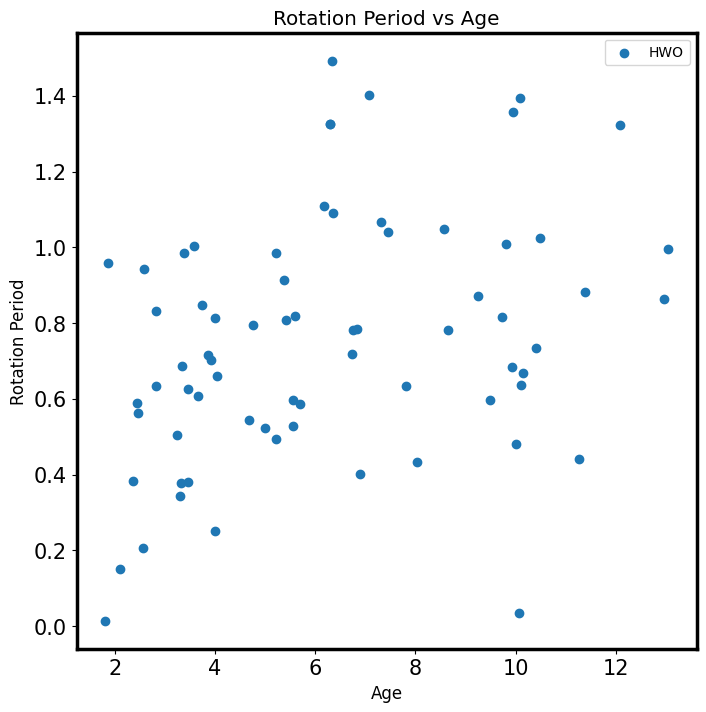

In [8]:
### Make a nice canvas for the figure
figure, axis = plt.subplots(figsize=(8,8))

### Add the data

axis.scatter(rottable_with_both['Age'],np.log10(rottable_with_both['rotation_period']),label='HWO')

### Set the x and y limits
#axis.set_xlim(0,10) # after you plot the full sample, choose a minimum and maximum BP-RP and activate this line
#axis.set_ylim(7.5,0) # same but for Gmag; recall that bright stars go on top and faint stars go on the bottom of a CMD

### Add axis labels
axis.set_xlabel('Age',fontsize='large') # Add axis labels. you can use the fontsize= keyword to change the font size.
axis.set_ylabel('Rotation Period',fontsize='large')

### Add title
axis.set_title('Rotation Period vs Age',fontsize='x-large') # Add a title.

# Make plot look nice
axis_border_width = 2.5
fontsize_axis_labels = 15
axis.tick_params(axis='both', which='major', labelsize=fontsize_axis_labels)
axis.spines['top'].set_linewidth(axis_border_width)
axis.spines['left'].set_linewidth(axis_border_width)
axis.spines['right'].set_linewidth(axis_border_width)
axis.spines['bottom'].set_linewidth(axis_border_width)
axis.legend()

# Conclude the figure
figure.show()

In [4]:
from astropy.table import Table

rottable_with_both = Table.read("rottable_with_both.csv", format="csv")
rottable_with_both

angDist,ra,dec,star_name,ra2,dec2,Age,rotation_period
float64,float64,float64,str14,float64,float64,float64,float64
0.10520677674997349,2.81607516478,-15.467977907889997,TIC 289673491,2.81604541137,-15.46798354267,3.859,5.200395
0.006020724256012122,249.08937370706997,-2.3245869511758324,TIC 58092025,249.08937204273,-2.32458677361,12.081,21.07
0.00716852406460896,147.14738061867,46.02100739317,TIC 23969522,147.14738042288,46.02100937978,7.819,4.296
0.011333202938870593,296.6066668696129,33.72759820378805,TIC 58445695,296.60666573585,33.72759520021,3.236,3.186301
0.0014741115626317693,243.90529281485533,-8.369439479286111,TIC 135656809,243.90529322864,-8.36943947035,9.946,22.7
0.008442704043549217,112.48315488244,49.67245940035,TIC 328324648,112.4831534377,49.67246155111,3.311,2.209643
0.0005014900542180958,273.4743033607241,64.39728493338667,TIC 233121747,273.47430328637,64.39728479784,2.815,4.293302
4.858516911776002,258.8365985355513,-26.601699224429723,TIC 1277142190,258.83743593135,-26.60282206323,6.304,21.11
0.017630472397238747,258.83743260923,-26.602825956905555,TIC 1277142190,258.83743593135,-26.60282206323,6.304,21.11


In [9]:
mass_table4 = Table.read("mass_table4_gyro_ages.csv", format="csv")
mass_table4


star_age,catalog_age,mass,rotation_period,name,fe_h,B-V,Teff_from_B-V,gyro_age_myr,gyro_age_gyr,gyro_age_peak_myr,gyro_age_mean_myr,gyro_age_plus1sigma_myr,gyro_age_minus1sigma_myr,gyro_age_note
float64,float64,float64,float64,str14,float64,float64,float64,float64,float64,float64,float64,float64,float64,str29
3.859,3.859,1.19,5.200395,TIC 289673491,-0.3400000035762787,0.4900000000000002,6329.999999999999,nan,nan,nan,nan,nan,nan,outside gyrointerp Teff range
12.081,12.081,0.91,21.07,TIC 58092025,nan,0.7800000000000002,5366.585365853658,2528.82,2.52882,2480.0,2551.52,263.58,216.79,--
7.819,7.819,1.06,4.296,TIC 23969522,0.09000000357627869,0.6200000000000001,5865.185185185185,243.98,0.24398,250.0,249.51,92.01,89.69,--
3.236,3.236,1.22,3.186301,TIC 58445695,0.009999999776482582,0.44899999999999984,6510.869565217392,nan,nan,nan,nan,nan,nan,outside gyrointerp Teff range
9.946,9.946,1.04,22.7,TIC 135656809,nan,0.6500000000000004,5769.999999999998,3459.12,3.45912,3470.0,3455.8,328.74,337.92,--
3.311,3.311,1.26,2.209643,TIC 328324648,-0.28999999165534973,0.4449999999999994,6528.26086956522,nan,nan,nan,nan,nan,nan,outside gyrointerp Teff range
2.815,2.815,1.32,4.293302,TIC 233121747,-0.17000000178813934,0.41999999999999993,6630.0,nan,nan,nan,nan,nan,nan,outside gyrointerp Teff range
6.304,6.304,nan,21.11,TIC 1277142190,-0.009999999776482582,0.8499999999999996,5187.073170731708,2413.11,2.41311,2370.0,2434.89,223.21,177.52,--
6.304,6.304,0.87,21.11,TIC 1277142190,-0.009999999776482582,0.8499999999999996,5187.073170731708,2413.11,2.41311,2370.0,2434.89,223.21,177.52,--


In [15]:
mass_table7 = Table.read("mass_table7.csv", format="csv")

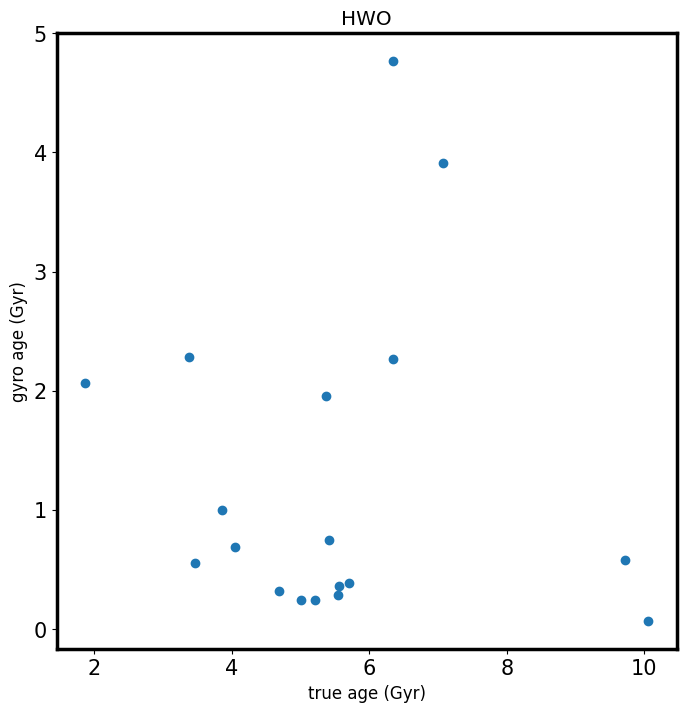

In [ ]:
##### Plot BP-RP vs Gmag #####

### Make a nice canvas for the figure
figure, axis = plt.subplots(figsize=(8,8))
#absmag = np.float64(hwo[3])-5*np.log10(np.float64(hwo[4]))+5
### Add the data
f_stars = mass_table7[
    [str(stellar_class).startswith("F") for stellar_class in mass_table7["stellar_class"]]
]

g_stars = mass_table7[
    [str(stellar_class).startswith("G") for stellar_class in mass_table7["stellar_class"]]
]

k_stars = mass_table7[
    [str(stellar_class).startswith("K") for stellar_class in mass_table7["stellar_class"]]
]  



axis.scatter(f_stars['star_age'], f_stars['gyro_age_gyr']) # add in your data here and delete the hashtag to activate the line.
axis.scatter(g_stars['star_age'], g_stars['gyro_age_gyr'], c='green') # add in your data here and delete the hashtag to activate the line.
axis.scatter(k_stars['star_age'], k_stars['gyro_age_gyr'], c='orange') # add in your data here and delete the hashtag to activate the line.

### Set the x and y limits
#axis.set_xlim(-1,4) # after you plot the full sample, choose a minimum and maximum BP-RP and activate this line
#axis.set_ylim(10,2) # same but for Gmag; recall that bright stars go on top and faint stars go on the bottom of a CMD

### Add axis labels
axis.set_xlabel('true age (Gyr)',fontsize='large') # Add axis labels. you can use the fontsize= keyword to change the font size.
axis.set_ylabel('gyro age (Gyr)',fontsize='large')

### Add title
axis.set_title('HWO',fontsize='x-large') # Add a title.

# Make plot look nice
axis_border_width = 2.5
fontsize_axis_labels = 15
axis.tick_params(axis='both', which='major', labelsize=fontsize_axis_labels)
axis.spines['top'].set_linewidth(axis_border_width)
axis.spines['left'].set_linewidth(axis_border_width)
axis.spines['right'].set_linewidth(axis_border_width)
axis.spines['bottom'].set_linewidth(axis_border_width)

# Conclude the figure
figure.show()